# IEEE Access Heat Benchmark — Clean, Scaled and Reviewer-Ready Kaggle T4 Notebook

This notebook implements a publication-grade benchmark for physics-consistent surrogate modeling of two-dimensional steady-state heat conduction. It generates or loads auditable datasets, applies train-only channel-wise standardization, trains CNN, GNN and eQELM surrogates, evaluates predictive and physics-consistency metrics, runs a physics-regularization ablation, and exports reviewer artifacts.

The workflow is written in English and is designed for a reproducible reviewer run on Kaggle with an NVIDIA T4 GPU.


## Reproducibility, scaling and scientific controls

This version emphasizes scientific reproducibility rather than informal experimentation. It fixes Python, NumPy and PyTorch seeds, requests deterministic PyTorch behavior, disables TF32 and mixed precision by default, uses seeded DataLoaders, stores raw arrays, stores train-only scaler statistics, audits scaling, records the runtime environment, exports package versions, records GPU information, produces dataset manifests and computes SHA-256 checksums.

Exact bitwise equality is not guaranteed across all GPU/runtime combinations, but the workflow is designed to produce stable, traceable and reviewer-auditable results under the same configuration.


In [1]:
from pathlib import Path
import os, sys, time, glob, json, math, random, shutil, zipfile, warnings, subprocess
warnings.filterwarnings("ignore")

os.environ.setdefault("PYTHONHASHSEED", "0")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

WORK_DIR = Path("/kaggle/working") if Path("/kaggle").exists() else Path(".")
DATA_DIR = WORK_DIR / "data"
RESULTS_DIR = WORK_DIR / "results"
FIGURES_DIR = WORK_DIR / "figures"
CHECKPOINTS_DIR = WORK_DIR / "checkpoints"
REVIEW_DIR = WORK_DIR / "reviewer_artifacts"
for p in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, CHECKPOINTS_DIR, REVIEW_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORK_DIR.resolve())
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("PyTorch not available:", e)

Working directory: /kaggle/working
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Core benchmark library

This cell defines the numerical solver, synthetic dataset generators, surrogate models, metrics, training loop and plotting utilities.


In [2]:

import os
import sys
import glob
import json
import math
import time
import random
import shutil
import zipfile
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from scipy import sparse
    from scipy.sparse.linalg import factorized
except Exception as e:
    sparse = None
    factorized = None

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    strict = bool(globals().get("STRICT_REPRODUCIBILITY", False))
    try:
        torch.backends.cudnn.deterministic = strict
        torch.backends.cudnn.benchmark = not strict
        if hasattr(torch.backends, "cuda"):
            torch.backends.cuda.matmul.allow_tf32 = False if strict else torch.backends.cuda.matmul.allow_tf32
        torch.backends.cudnn.allow_tf32 = False if strict else torch.backends.cudnn.allow_tf32
        if strict:
            torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as exc:
        if strict:
            print("Deterministic setup warning:", exc)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    return Path(path)


def write_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)



def list_kaggle_input_files(root="/kaggle/input", exts=(".npz", ".npy", ".h5", ".hdf5", ".mat", ".csv", ".zip")):
    files = []
    root = Path(root)
    if not root.exists():
        return files
    for ext in exts:
        files.extend([str(p) for p in root.rglob(f"*{ext}")])
    return sorted(files)


def download_url(url: str, out_path: str, chunk_size=1024 * 1024):
    """Download a file from a direct URL. Requires internet enabled in Kaggle."""
    import requests
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        done = 0
        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    done += len(chunk)
                    if total:
                        print(f"\rDownloaded {done/1e6:.1f}/{total/1e6:.1f} MB", end="")
    print(f"\nSaved to {out_path}")
    return str(out_path)


def kaggle_dataset_download(slug: str, out_dir: str = "/kaggle/working/external_dataset", unzip=True):
    """
    Download a Kaggle dataset by slug, e.g. 'owner/dataset-name'.
    Requires Kaggle API credentials and internet enabled.
    In Kaggle notebooks, the safest path is often: Add Data -> dataset, then read /kaggle/input.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if not slug:
        raise ValueError("KAGGLE_DATASET_SLUG is empty.")
    cmd = ["kaggle", "datasets", "download", "-d", slug, "-p", str(out_dir)]
    if unzip:
        cmd.append("--unzip")
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
    return str(out_dir)



_POISSON_FACTORS = {}

def _build_poisson_factor(n: int):
    if sparse is None or factorized is None:
        raise ImportError("scipy is required for synthetic heat-equation generation.")
    if n in _POISSON_FACTORS:
        return _POISSON_FACTORS[n]
    m = n - 2
    N = m * m

    main = 4.0 * np.ones(N)
    left_right = -1.0 * np.ones(N - 1)
    for k in range(1, m):
        left_right[k * m - 1] = 0.0
    up_down = -1.0 * np.ones(N - m)

    A = sparse.diags(
        diagonals=[main, left_right, left_right, up_down, up_down],
        offsets=[0, -1, 1, -m, m],
        shape=(N, N),
        format="csc",
    )
    solve = factorized(A)
    _POISSON_FACTORS[n] = solve
    return solve


def solve_poisson_dirichlet(q, bc):
    """
    Solve -Laplace(T) = q on a square grid with Dirichlet boundary values.
    The finite-difference system is:
        4*T_ij - neighbors = h^2*q_ij + boundary contributions
    """
    n = q.shape[0]
    h = 1.0 / (n - 1)
    m = n - 2
    rhs = (h * h) * q[1:-1, 1:-1].copy()

    rhs[0, :] += bc[0, 1:-1]       # top boundary
    rhs[-1, :] += bc[-1, 1:-1]     # bottom boundary
    rhs[:, 0] += bc[1:-1, 0]       # left boundary
    rhs[:, -1] += bc[1:-1, -1]     # right boundary

    solve = _build_poisson_factor(n)
    interior = solve(rhs.reshape(-1)).reshape(m, m)

    T = bc.copy()
    T[1:-1, 1:-1] = interior
    return T


def make_boundary(n, rng, variant="D6"):
    bc = np.zeros((n, n), dtype=np.float32)
    if variant.upper() in ["D6", "D6_SYNTH", "D6-SYNTH"]:
        return bc

    x = np.linspace(0, 1, n, dtype=np.float32)
    y = np.linspace(0, 1, n, dtype=np.float32)

    amp1 = rng.uniform(0.05, 0.35)
    amp2 = rng.uniform(0.05, 0.35)
    phase = rng.uniform(0, 2 * np.pi)

    bc[:, 0] = amp1 * np.sin(np.pi * y + phase)
    bc[:, -1] = amp2 * np.cos(np.pi * y + phase / 2)
    bc[0, :] = 0.5 * amp1 * np.sin(2 * np.pi * x + phase)
    bc[-1, :] = 0.5 * amp2 * np.cos(2 * np.pi * x + phase)

    return bc.astype(np.float32)


def make_heat_source(n, rng, variant="D6"):
    xs = np.linspace(0, 1, n, dtype=np.float32)
    ys = np.linspace(0, 1, n, dtype=np.float32)
    Xg, Yg = np.meshgrid(xs, ys)
    q = np.zeros((n, n), dtype=np.float32)

    n_blobs = int(rng.integers(1, 5))
    for _ in range(n_blobs):
        cx, cy = rng.uniform(0.15, 0.85, size=2)
        amp = rng.uniform(2.0, 12.0)
        if variant.upper().startswith("D8"):
            sx = rng.uniform(0.025, 0.13)
            sy = rng.uniform(0.025, 0.16)
        else:
            sx = sy = rng.uniform(0.035, 0.12)
        q += amp * np.exp(-(((Xg - cx) ** 2) / (2 * sx ** 2) + ((Yg - cy) ** 2) / (2 * sy ** 2)))

    if rng.random() < (0.25 if variant.upper().startswith("D8") else 0.10):
        x0, y0 = rng.uniform(0.10, 0.70, size=2)
        w, h = rng.uniform(0.08, 0.22, size=2)
        amp = rng.uniform(1.0, 8.0)
        q[((Xg >= x0) & (Xg <= x0 + w) & (Yg >= y0) & (Yg <= y0 + h))] += amp

    q[0, :] = q[-1, :] = q[:, 0] = q[:, -1] = 0.0
    return q.astype(np.float32)


def generate_heat_dataset(
    out_path,
    variant="D6",
    n_samples=3000,
    n_grid=25,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=123,
    verbose=True,
):
    """
    Generate a synthetic 2D heat-conduction surrogate dataset:
      input X has 3 channels: [heat_source_q, boundary_value, boundary_mask]
      target y has 1 channel: [temperature_field_T]
    """
    set_seed(seed)
    rng = np.random.default_rng(seed)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    X = np.zeros((n_samples, 3, n_grid, n_grid), dtype=np.float32)
    y = np.zeros((n_samples, 1, n_grid, n_grid), dtype=np.float32)

    boundary_mask = np.zeros((n_grid, n_grid), dtype=np.float32)
    boundary_mask[0, :] = boundary_mask[-1, :] = boundary_mask[:, 0] = boundary_mask[:, -1] = 1.0

    for i in range(n_samples):
        q = make_heat_source(n_grid, rng, variant=variant)
        bc = make_boundary(n_grid, rng, variant=variant)
        T = solve_poisson_dirichlet(q, bc)

        X[i, 0] = q
        X[i, 1] = bc
        X[i, 2] = boundary_mask
        y[i, 0] = T

        if verbose and (i + 1) % max(1, n_samples // 10) == 0:
            print(f"{variant}: generated {i+1}/{n_samples}")

    idx = np.arange(n_samples)
    rng.shuffle(idx)
    X, y = X[idx], y[idx]

    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
    X_test, y_test = X[n_train + n_val:], y[n_train + n_val:]

    x_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
    x_std = X_train.std(axis=(0, 2, 3), keepdims=True) + 1e-8
    y_mean = y_train.mean(axis=(0, 2, 3), keepdims=True)
    y_std = y_train.std(axis=(0, 2, 3), keepdims=True) + 1e-8

    X_train_n = (X_train - x_mean) / x_std
    X_val_n = (X_val - x_mean) / x_std
    X_test_n = (X_test - x_mean) / x_std
    y_train_n = (y_train - y_mean) / y_std
    y_val_n = (y_val - y_mean) / y_std
    y_test_n = (y_test - y_mean) / y_std

    np.savez_compressed(
        out_path,
        X_train=X_train_n, y_train=y_train_n,
        X_val=X_val_n, y_val=y_val_n,
        X_test=X_test_n, y_test=y_test_n,
        x_mean=x_mean, x_std=x_std, y_mean=y_mean, y_std=y_std,
        variant=np.array(variant), n_grid=np.array(n_grid),
        X_train_raw=X_train, y_train_raw=y_train,
        X_val_raw=X_val, y_val_raw=y_val,
        X_test_raw=X_test, y_test_raw=y_test,
    )
    print(f"Saved {variant} dataset to: {out_path}")
    print(f"Splits: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
    return str(out_path)


def prepare_datasets(
    data_dir="/kaggle/working/data",
    dataset_source="synthetic",
    kaggle_slug="",
    dataset_url="",
    n_grid=25,
    n_samples_d6=3000,
    n_samples_d8=3000,
    seed=123,
):
    """
    Prepare D6 and D8-var datasets.
    dataset_source:
      - 'kaggle_input': searches /kaggle/input for dataset_D6.npz and dataset_D8var.npz
      - 'kaggle_api': downloads a Kaggle dataset slug, then searches files
      - 'url': downloads direct URL
      - 'synthetic': generates D6 and D8-var datasets
    """
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    print("Dataset source:", dataset_source)

    if dataset_source == "kaggle_api":
        kaggle_dataset_download(kaggle_slug, out_dir=str(data_dir / "external"), unzip=True)

    if dataset_source == "url":
        if not dataset_url:
            raise ValueError("DATASET_URL is empty.")
        raw_path = data_dir / "downloaded_dataset"
        suffix = Path(dataset_url.split("?")[0]).suffix or ".bin"
        raw_file = str(raw_path) + suffix
        downloaded = download_url(dataset_url, raw_file)
        if downloaded.endswith(".zip"):
            with zipfile.ZipFile(downloaded, "r") as z:
                z.extractall(data_dir / "external")

    search_roots = [data_dir, Path("/kaggle/input")]
    found = []
    for root in search_roots:
        if root.exists():
            found.extend([str(p) for p in root.rglob("*.npz")])

    def find_by_name(names):
        for fp in found:
            low = Path(fp).name.lower()
            if all(name.lower() in low for name in names):
                return fp
        return None

    d6 = find_by_name(["d6"])
    d8 = find_by_name(["d8"]) or find_by_name(["d8var"])

    if d6:
        dst = data_dir / "dataset_D6.npz"
        if Path(d6).resolve() != dst.resolve():
            shutil.copy(d6, dst)
        print("Found D6:", d6)
    if d8:
        dst = data_dir / "dataset_D8var.npz"
        if Path(d8).resolve() != dst.resolve():
            shutil.copy(d8, dst)
        print("Found D8/D8var:", d8)

    if dataset_source == "synthetic" or not (data_dir / "dataset_D6.npz").exists():
        generate_heat_dataset(data_dir / "dataset_D6.npz", "D6", n_samples_d6, n_grid=n_grid, seed=seed)
    if dataset_source == "synthetic" or not (data_dir / "dataset_D8var.npz").exists():
        generate_heat_dataset(data_dir / "dataset_D8var.npz", "D8var", n_samples_d8, n_grid=n_grid, seed=seed + 999)

    return {
        "D6": str(data_dir / "dataset_D6.npz"),
        "D8var": str(data_dir / "dataset_D8var.npz"),
    }



class HeatNPZDataset(Dataset):
    def __init__(self, npz_path, split="train"):
        self.path = str(npz_path)
        self.split = split
        z = np.load(npz_path, allow_pickle=True)
        self.X = z[f"X_{split}"].astype(np.float32)
        self.y = z[f"y_{split}"].astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.y[idx])


def load_npz_arrays(npz_path, split):
    z = np.load(npz_path, allow_pickle=True)
    return z[f"X_{split}"].astype(np.float32), z[f"y_{split}"].astype(np.float32)


def load_stats(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    return {
        "x_mean": torch.tensor(z["x_mean"], dtype=torch.float32),
        "x_std": torch.tensor(z["x_std"], dtype=torch.float32),
        "y_mean": torch.tensor(z["y_mean"], dtype=torch.float32),
        "y_std": torch.tensor(z["y_std"], dtype=torch.float32),
        "n_grid": int(z["n_grid"]) if "n_grid" in z else int(z["X_train"].shape[-1]),
    }


def denorm_x(x, stats, device=None):
    mean = stats["x_mean"]
    std = stats["x_std"]
    if device is not None:
        mean = mean.to(device)
        std = std.to(device)
    return x * std + mean


def denorm_y(y, stats, device=None):
    mean = stats["y_mean"]
    std = stats["y_std"]
    if device is not None:
        mean = mean.to(device)
        std = std.to(device)
    return y * std + mean



class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32, dropout=0.0):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base, dropout)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base * 2, dropout)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 2, base * 4, dropout)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2, dropout)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base, dropout)
        self.out = nn.Conv2d(base, out_ch, 1)

    def _crop_or_pad(self, x, ref):
        diff_y = ref.size(-2) - x.size(-2)
        diff_x = ref.size(-1) - x.size(-1)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        return x

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        u2 = self._crop_or_pad(self.up2(b), e2)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self._crop_or_pad(self.up1(d2), e1)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))
        return self.out(d1)


def make_grid_adjacency(n_grid=25, self_loops=True):
    N = n_grid * n_grid
    A = np.zeros((N, N), dtype=np.float32)

    def node(i, j):
        return i * n_grid + j

    for i in range(n_grid):
        for j in range(n_grid):
            u = node(i, j)
            if self_loops:
                A[u, u] = 1.0
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ii, jj = i + di, j + dj
                if 0 <= ii < n_grid and 0 <= jj < n_grid:
                    v = node(ii, jj)
                    A[u, v] = 1.0
    deg = A.sum(axis=1, keepdims=True) + 1e-8
    A = A / deg
    return torch.tensor(A, dtype=torch.float32)


def make_coord_features(n_grid=25, batch_size=1, device="cpu"):
    xs = torch.linspace(0, 1, n_grid, device=device)
    ys = torch.linspace(0, 1, n_grid, device=device)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)
    return coords.unsqueeze(0).repeat(batch_size, 1, 1)


class DenseGraphConv(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Sequential(
            nn.Linear(in_dim * 2, out_dim),
            nn.GELU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.LayerNorm(out_dim),
        )

    def forward(self, x, A):
        agg = torch.einsum("ij,bjf->bif", A, x)
        return self.lin(torch.cat([x, agg], dim=-1))


class GridGNN(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, n_grid=25, hidden=96, layers=4, dropout=0.0):
        super().__init__()
        self.n_grid = n_grid
        self.register_buffer("A", make_grid_adjacency(n_grid))
        in_dim = in_ch + 2
        convs = []
        convs.append(DenseGraphConv(in_dim, hidden, dropout))
        for _ in range(layers - 1):
            convs.append(DenseGraphConv(hidden, hidden, dropout))
        self.convs = nn.ModuleList(convs)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_ch),
        )

    def forward(self, x):
        B, C, H, W = x.shape
        node_x = x.permute(0, 2, 3, 1).reshape(B, H * W, C)
        coords = make_coord_features(H, B, device=x.device)
        h = torch.cat([node_x, coords], dim=-1)
        A = self.A.to(x.device)
        for conv in self.convs:
            h = conv(h, A)
        out = self.head(h).reshape(B, H, W, 1).permute(0, 3, 1, 2)
        return out


class EQELMRegressor:
    """
    Quantum-inspired ELM using random Fourier-style features:
        phi(x) = [cos(xW+b), sin(xW+b)]
    Then closed-form ridge regression to predict the full temperature field.
    """
    def __init__(self, input_dim, output_dim, hidden=512, ridge=1e-3, sigma=1.0, seed=42, device=None):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden = hidden
        self.ridge = ridge
        self.sigma = sigma
        self.seed = seed
        self.device = device or get_device()
        g = torch.Generator(device="cpu")
        g.manual_seed(seed)
        self.W = torch.randn(input_dim, hidden, generator=g) * sigma / math.sqrt(input_dim)
        self.b = 2 * math.pi * torch.rand(hidden, generator=g)
        self.beta = None

    def _features(self, X):
        W = self.W.to(X.device)
        b = self.b.to(X.device)
        Z = X @ W + b
        Phi = torch.cat([torch.cos(Z), torch.sin(Z)], dim=1) / math.sqrt(self.hidden)
        return Phi

    def fit(self, X_np, Y_np, batch_size=4096):
        device = self.device
        X = torch.tensor(X_np.reshape(len(X_np), -1), dtype=torch.float32, device=device)
        Y = torch.tensor(Y_np.reshape(len(Y_np), -1), dtype=torch.float32, device=device)
        phis = []
        with torch.no_grad():
            for i in range(0, len(X), batch_size):
                phis.append(self._features(X[i:i + batch_size]).detach())
            Phi = torch.cat(phis, dim=0)
            I = torch.eye(Phi.shape[1], device=device)
            A = Phi.T @ Phi + self.ridge * I
            B = Phi.T @ Y
            self.beta = torch.linalg.solve(A, B).detach()
        return self

    def predict(self, X_np, batch_size=4096):
        if self.beta is None:
            raise RuntimeError("Model not fitted yet.")
        device = self.device
        X = torch.tensor(X_np.reshape(len(X_np), -1), dtype=torch.float32, device=device)
        preds = []
        with torch.no_grad():
            for i in range(0, len(X), batch_size):
                Phi = self._features(X[i:i + batch_size])
                preds.append((Phi @ self.beta).detach().cpu())
        return torch.cat(preds, dim=0).numpy()



def laplacian2d(t):
    """
    Discrete Laplacian on interior points.
    t shape: [B,1,H,W]
    """
    H = t.shape[-2]
    h = 1.0 / (H - 1)
    center = t[:, :, 1:-1, 1:-1]
    lap = (
        t[:, :, :-2, 1:-1] + t[:, :, 2:, 1:-1] +
        t[:, :, 1:-1, :-2] + t[:, :, 1:-1, 2:] -
        4.0 * center
    ) / (h * h)
    return lap


def physics_residual_loss(pred_norm, x_norm, stats, reduction="mean"):
    device = pred_norm.device
    pred = denorm_y(pred_norm, stats, device=device)
    x_raw = denorm_x(x_norm, stats, device=device)
    q = x_raw[:, 0:1]
    residual = laplacian2d(pred) + q[:, :, 1:-1, 1:-1]
    val = residual.abs()
    return val.mean() if reduction == "mean" else val


def boundary_flux_error(pred, target):
    gp_top = pred[:, :, 1, :] - pred[:, :, 0, :]
    gt_top = target[:, :, 1, :] - target[:, :, 0, :]
    gp_bot = pred[:, :, -1, :] - pred[:, :, -2, :]
    gt_bot = target[:, :, -1, :] - target[:, :, -2, :]
    gp_left = pred[:, :, :, 1] - pred[:, :, :, 0]
    gt_left = target[:, :, :, 1] - target[:, :, :, 0]
    gp_right = pred[:, :, :, -1] - pred[:, :, :, -2]
    gt_right = target[:, :, :, -1] - target[:, :, :, -2]
    vals = [
        (gp_top - gt_top).abs().mean(),
        (gp_bot - gt_bot).abs().mean(),
        (gp_left - gt_left).abs().mean(),
        (gp_right - gt_right).abs().mean(),
    ]
    return torch.stack(vals).mean()


def fft_error(pred, target):
    err = pred[:, 0] - target[:, 0]
    spec = torch.fft.rfft2(err).abs()
    return spec.mean()


def regional_mae(pred, target):
    H, W = pred.shape[-2], pred.shape[-1]
    center = pred[:, :, H//4:3*H//4, W//4:3*W//4]
    center_t = target[:, :, H//4:3*H//4, W//4:3*W//4]
    boundary_mask = torch.zeros_like(pred)
    boundary_mask[:, :, 0, :] = boundary_mask[:, :, -1, :] = 1
    boundary_mask[:, :, :, 0] = boundary_mask[:, :, :, -1] = 1
    boundary_err = ((pred - target).abs() * boundary_mask).sum() / boundary_mask.sum().clamp_min(1)
    return {
        "mae_center": (center - center_t).abs().mean(),
        "mae_boundary": boundary_err,
    }


def count_parameters(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def estimate_model_size_mb(model):
    total = 0
    for p in model.parameters():
        total += p.numel() * p.element_size()
    return total / (1024 ** 2)


def evaluate_deep_model(model, loader, stats, device=None, max_latency_batches=20):
    device = device or get_device()
    model.eval()
    sse = 0.0
    sae = 0.0
    n_elem = 0
    y_sum = 0.0
    y_sq_sum = 0.0
    physics_vals = []
    flux_vals = []
    fft_vals = []
    center_vals = []
    boundary_vals = []

    latencies = []
    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(loader):
            x = x.to(device)
            y = y.to(device)

            if batch_idx < max_latency_batches:
                if device.type == "cuda":
                    torch.cuda.synchronize()
                t0 = time.time()
                pred_norm = model(x)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                latencies.append((time.time() - t0) / max(1, len(x)))
            else:
                pred_norm = model(x)

            pred = denorm_y(pred_norm, stats, device=device)
            target = denorm_y(y, stats, device=device)

            err = pred - target
            sse += float((err ** 2).sum().detach().cpu())
            sae += float(err.abs().sum().detach().cpu())
            n_elem += err.numel()
            y_sum += float(target.sum().detach().cpu())
            y_sq_sum += float((target ** 2).sum().detach().cpu())

            physics_vals.append(float(physics_residual_loss(pred_norm, x, stats).detach().cpu()))
            flux_vals.append(float(boundary_flux_error(pred, target).detach().cpu()))
            fft_vals.append(float(fft_error(pred, target).detach().cpu()))
            regs = regional_mae(pred, target)
            center_vals.append(float(regs["mae_center"].detach().cpu()))
            boundary_vals.append(float(regs["mae_boundary"].detach().cpu()))

    rmse = math.sqrt(sse / max(1, n_elem))
    mae = sae / max(1, n_elem)
    y_mean = y_sum / max(1, n_elem)
    sst = y_sq_sum - n_elem * (y_mean ** 2)
    r2 = 1.0 - sse / max(1e-12, sst)
    latency_ms = 1000.0 * float(np.mean(latencies)) if latencies else np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "physics_error": float(np.mean(physics_vals)),
        "boundary_flux_error": float(np.mean(flux_vals)),
        "fft_error": float(np.mean(fft_vals)),
        "mae_center": float(np.mean(center_vals)),
        "mae_boundary": float(np.mean(boundary_vals)),
        "latency_ms": latency_ms,
    }


def evaluate_eqelm_predictions(pred_norm_np, x_norm_np, y_norm_np, stats, device=None, batch_size=512):
    device = device or get_device()
    sse = sae = y_sum = y_sq_sum = 0.0
    n_elem = 0
    physics_vals, flux_vals, fft_vals, center_vals, boundary_vals = [], [], [], [], []
    n = len(pred_norm_np)

    with torch.no_grad():
        for i in range(0, n, batch_size):
            pred_norm = torch.tensor(pred_norm_np[i:i+batch_size], dtype=torch.float32, device=device)
            x_norm = torch.tensor(x_norm_np[i:i+batch_size], dtype=torch.float32, device=device)
            y_norm = torch.tensor(y_norm_np[i:i+batch_size], dtype=torch.float32, device=device)

            B = len(pred_norm)
            H = stats["n_grid"]
            pred_norm = pred_norm.reshape(B, 1, H, H)
            y_norm = y_norm.reshape(B, 1, H, H)

            pred = denorm_y(pred_norm, stats, device=device)
            target = denorm_y(y_norm, stats, device=device)
            err = pred - target

            sse += float((err ** 2).sum().detach().cpu())
            sae += float(err.abs().sum().detach().cpu())
            n_elem += err.numel()
            y_sum += float(target.sum().detach().cpu())
            y_sq_sum += float((target ** 2).sum().detach().cpu())

            physics_vals.append(float(physics_residual_loss(pred_norm, x_norm, stats).detach().cpu()))
            flux_vals.append(float(boundary_flux_error(pred, target).detach().cpu()))
            fft_vals.append(float(fft_error(pred, target).detach().cpu()))
            regs = regional_mae(pred, target)
            center_vals.append(float(regs["mae_center"].detach().cpu()))
            boundary_vals.append(float(regs["mae_boundary"].detach().cpu()))

    rmse = math.sqrt(sse / max(1, n_elem))
    mae = sae / max(1, n_elem)
    y_mean = y_sum / max(1, n_elem)
    sst = y_sq_sum - n_elem * y_mean ** 2
    r2 = 1.0 - sse / max(1e-12, sst)
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "physics_error": float(np.mean(physics_vals)),
        "boundary_flux_error": float(np.mean(flux_vals)),
        "fft_error": float(np.mean(fft_vals)),
        "mae_center": float(np.mean(center_vals)),
        "mae_boundary": float(np.mean(boundary_vals)),
    }



def make_model(model_name, n_grid=25, in_ch=3):
    name = model_name.lower()
    if name in ["cnn", "unet", "convnet"]:
        return SmallUNet(in_ch=in_ch, out_ch=1, base=32, dropout=0.02)
    if name in ["gnn", "gridgnn", "graph"]:
        return GridGNN(in_ch=in_ch, out_ch=1, n_grid=n_grid, hidden=96, layers=4, dropout=0.02)
    raise ValueError(f"Unknown model: {model_name}")


def train_deep_model(
    npz_path,
    dataset_name,
    model_name,
    seed=0,
    lambda_physics=1e-3,
    epochs=80,
    batch_size=64,
    lr=2e-3,
    weight_decay=1e-4,
    patience=15,
    work_dir="/kaggle/working",
    num_workers=2,
    force=False,
):
    set_seed(seed)
    device = get_device()
    work_dir = Path(work_dir)
    ckpt_dir = work_dir / "checkpoints"
    result_dir = work_dir / "results"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    stats = load_stats(npz_path)
    n_grid = stats["n_grid"]
    run_id = f"{dataset_name}_{model_name}_seed{seed}_lambda{lambda_physics:g}"
    ckpt_path = ckpt_dir / f"{run_id}.pt"

    train_ds = HeatNPZDataset(npz_path, "train")
    val_ds = HeatNPZDataset(npz_path, "val")
    test_ds = HeatNPZDataset(npz_path, "test")

    if bool(globals().get("STRICT_REPRODUCIBILITY", False)):
        num_workers = 0
        dl_generator = torch.Generator()
        dl_generator.manual_seed(int(seed))
    else:
        dl_generator = None

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, generator=dl_generator)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    in_ch = int(train_ds.X.shape[1])
    model = make_model(model_name, n_grid=n_grid, in_ch=in_ch).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, epochs))
    use_amp = bool(device.type == "cuda" and globals().get("USE_MIXED_PRECISION", False))
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_val = float("inf")
    best_epoch = -1
    no_improve = 0
    history = []

    start_time = time.time()
    if ckpt_path.exists() and not force:
        print(f"Checkpoint exists, loading: {ckpt_path}")
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state["model"])
        best_epoch = state.get("epoch", -1)
    else:
        for epoch in range(1, epochs + 1):
            model.train()
            train_losses = []
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    pred = model(x)
                    data_loss = F.mse_loss(pred, y)
                    phys_loss = physics_residual_loss(pred, x, stats)
                    loss = data_loss + lambda_physics * phys_loss
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
                train_losses.append(float(loss.detach().cpu()))
            scheduler.step()

            val_metrics = evaluate_deep_model(model, val_loader, stats, device=device, max_latency_batches=0)
            val_loss = val_metrics["rmse"]
            row = {
                "epoch": epoch,
                "train_loss": float(np.mean(train_losses)),
                "val_rmse": val_metrics["rmse"],
                "val_mae": val_metrics["mae"],
                "val_r2": val_metrics["r2"],
                "val_physics_error": val_metrics["physics_error"],
            }
            history.append(row)

            if val_loss < best_val:
                best_val = val_loss
                best_epoch = epoch
                no_improve = 0
                torch.save({
                    "model": model.state_dict(),
                    "epoch": epoch,
                    "best_val": best_val,
                    "config": {
                        "dataset_name": dataset_name,
                        "model_name": model_name,
                        "seed": seed,
                        "lambda_physics": lambda_physics,
                    },
                }, ckpt_path)
            else:
                no_improve += 1

            if epoch == 1 or epoch % 5 == 0:
                print(f"[{run_id}] epoch={epoch:03d} train={np.mean(train_losses):.5f} val_rmse={val_metrics['rmse']:.5f} phys={val_metrics['physics_error']:.5f}")

            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}, best epoch {best_epoch}")
                break

        pd.DataFrame(history).to_csv(result_dir / f"history_{run_id}.csv", index=False)
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state["model"])

    test_metrics = evaluate_deep_model(model, test_loader, stats, device=device)
    train_time = time.time() - start_time

    result = {
        "dataset": dataset_name,
        "model": model_name,
        "seed": seed,
        "lambda_physics": lambda_physics,
        "epochs_requested": epochs,
        "best_epoch": best_epoch,
        "training_time_sec": train_time,
        "params": count_parameters(model),
        "model_size_mb": estimate_model_size_mb(model),
        **test_metrics,
    }
    print("TEST:", result)
    return result


def train_eqelm_model(
    npz_path,
    dataset_name,
    seed=0,
    hidden=512,
    ridge=1e-3,
    work_dir="/kaggle/working",
    batch_size=4096,
):
    set_seed(seed)
    device = get_device()
    work_dir = Path(work_dir)
    result_dir = work_dir / "results"
    result_dir.mkdir(parents=True, exist_ok=True)

    stats = load_stats(npz_path)
    X_train, y_train = load_npz_arrays(npz_path, "train")
    X_test, y_test = load_npz_arrays(npz_path, "test")

    input_dim = int(np.prod(X_train.shape[1:]))
    output_dim = int(np.prod(y_train.shape[1:]))

    model = EQELMRegressor(input_dim, output_dim, hidden=hidden, ridge=ridge, seed=seed, device=device)
    t0 = time.time()
    model.fit(X_train, y_train, batch_size=batch_size)
    training_time = time.time() - t0

    n_latency = min(256, len(X_test))
    if device.type == "cuda":
        torch.cuda.synchronize()
    t1 = time.time()
    preds_small = model.predict(X_test[:n_latency], batch_size=batch_size)
    if device.type == "cuda":
        torch.cuda.synchronize()
    latency_ms = 1000.0 * (time.time() - t1) / max(1, n_latency)

    preds = model.predict(X_test, batch_size=batch_size)
    metrics = evaluate_eqelm_predictions(preds, X_test, y_test, stats, device=device)

    result = {
        "dataset": dataset_name,
        "model": "eQELM",
        "seed": seed,
        "lambda_physics": 0.0,
        "epochs_requested": 0,
        "best_epoch": 0,
        "training_time_sec": training_time,
        "params": int(input_dim * hidden + hidden + (2 * hidden) * output_dim),
        "model_size_mb": np.nan,
        "latency_ms": latency_ms,
        **metrics,
        "eqelm_hidden": hidden,
        "eqelm_ridge": ridge,
    }
    print("TEST:", result)
    return result


def append_results(results, csv_path):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    df_new = pd.DataFrame(results if isinstance(results, list) else [results])
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df = pd.concat([df, df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(csv_path, index=False)
    return df


def result_exists(csv_path, dataset, model, seed, lambda_physics):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return False
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        return False
    mask = (
        (df["dataset"].astype(str) == str(dataset)) &
        (df["model"].astype(str).str.lower() == str(model).lower()) &
        (df["seed"].astype(int) == int(seed)) &
        (np.isclose(df["lambda_physics"].astype(float), float(lambda_physics)))
    )
    return bool(mask.any())


def run_main_experiments(
    dataset_paths,
    models=("cnn", "gnn", "eqelm"),
    seeds=(0, 1, 2, 3, 4),
    lambda_physics=1e-3,
    epochs=80,
    batch_size=64,
    work_dir="/kaggle/working",
    force=False,
):
    results_csv = Path(work_dir) / "results" / "results_ieee_access.csv"
    all_results = []
    for dataset_name, npz_path in dataset_paths.items():
        for model_name in models:
            for seed in seeds:
                lam = 0.0 if model_name.lower() == "eqelm" else lambda_physics
                if result_exists(results_csv, dataset_name, "eQELM" if model_name.lower()=="eqelm" else model_name, seed, lam) and not force:
                    print(f"Skipping existing result: {dataset_name}, {model_name}, seed={seed}, lambda={lam}")
                    continue
                if model_name.lower() == "eqelm":
                    res = train_eqelm_model(npz_path, dataset_name, seed=seed, work_dir=work_dir)
                else:
                    res = train_deep_model(
                        npz_path=npz_path,
                        dataset_name=dataset_name,
                        model_name=model_name,
                        seed=seed,
                        lambda_physics=lam,
                        epochs=epochs,
                        batch_size=batch_size,
                        work_dir=work_dir,
                        force=force,
                    )
                append_results(res, results_csv)
                all_results.append(res)
    return pd.read_csv(results_csv)


def run_lambda_ablation(
    dataset_paths,
    dataset_name="D6",
    model_name="cnn",
    seeds=(0, 1, 2, 3, 4),
    lambdas=(0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0),
    epochs=60,
    batch_size=64,
    work_dir="/kaggle/working",
    force=False,
):
    results_csv = Path(work_dir) / "results" / "results_lambda_ablation.csv"
    all_results = []
    npz_path = dataset_paths[dataset_name]
    for lam in lambdas:
        for seed in seeds:
            if result_exists(results_csv, dataset_name, model_name, seed, lam) and not force:
                print(f"Skipping existing ablation: {dataset_name}, {model_name}, seed={seed}, lambda={lam}")
                continue
            res = train_deep_model(
                npz_path=npz_path,
                dataset_name=dataset_name,
                model_name=model_name,
                seed=seed,
                lambda_physics=lam,
                epochs=epochs,
                batch_size=batch_size,
                work_dir=work_dir,
                force=force,
            )
            append_results(res, results_csv)
            all_results.append(res)
    return pd.read_csv(results_csv)



def summarize_mean_std(csv_path, group_cols=("dataset", "model")):
    df = pd.read_csv(csv_path)
    metrics = ["rmse", "mae", "r2", "physics_error", "boundary_flux_error", "fft_error", "latency_ms", "training_time_sec", "params"]
    rows = []
    for keys, g in df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        for m in metrics:
            if m in g.columns:
                row[f"{m}_mean"] = g[m].mean()
                row[f"{m}_std"] = g[m].std(ddof=1) if len(g) > 1 else 0.0
                row[f"{m}_fmt"] = f"{g[m].mean():.4g} ± {g[m].std(ddof=1) if len(g)>1 else 0.0:.2g}"
        rows.append(row)
    return pd.DataFrame(rows)


def wilcoxon_tests(csv_path, metric="rmse", baseline_model="cnn"):
    """
    Pairwise Wilcoxon signed-rank tests by dataset, comparing same seeds.
    Requires scipy.
    """
    try:
        from scipy.stats import wilcoxon
    except Exception:
        print("scipy.stats.wilcoxon unavailable.")
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    out = []
    for dataset, gd in df.groupby("dataset"):
        base = gd[gd["model"].str.lower() == baseline_model.lower()][["seed", metric]].rename(columns={metric: "baseline"})
        for model in gd["model"].unique():
            if model.lower() == baseline_model.lower():
                continue
            comp = gd[gd["model"] == model][["seed", metric]].rename(columns={metric: "comp"})
            merged = pd.merge(base, comp, on="seed")
            if len(merged) >= 2:
                stat, p = wilcoxon(merged["baseline"], merged["comp"])
                out.append({"dataset": dataset, "baseline": baseline_model, "model": model, "metric": metric, "n": len(merged), "statistic": stat, "p_value": p})
    return pd.DataFrame(out)


def plot_pareto(csv_path, out_path="/kaggle/working/figures/pareto_precision_physics.png"):
    import matplotlib.pyplot as plt
    df = pd.read_csv(csv_path)
    summary = df.groupby(["dataset", "model"], as_index=False).agg(
        rmse=("rmse", "mean"),
        physics_error=("physics_error", "mean"),
        rmse_std=("rmse", "std"),
        physics_std=("physics_error", "std"),
    )
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(8, 6))
    for _, row in summary.iterrows():
        plt.scatter(row["rmse"], row["physics_error"], s=80)
        plt.text(row["rmse"], row["physics_error"], f'{row["dataset"]}-{row["model"]}', fontsize=9)
    plt.xlabel("RMSE ↓")
    plt.ylabel("Physics residual error ↓")
    plt.title("Pareto: precision vs physical consistency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


def plot_metric_bars(csv_path, metric="rmse", out_path=None):
    import matplotlib.pyplot as plt
    df = pd.read_csv(csv_path)
    summary = df.groupby(["dataset", "model"], as_index=False).agg(mean=(metric, "mean"), std=(metric, "std"))
    labels = [f"{d}-{m}" for d, m in zip(summary["dataset"], summary["model"])]
    out_path = out_path or f"/kaggle/working/figures/{metric}_bars.png"
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, 5))
    plt.bar(labels, summary["mean"], yerr=summary["std"].fillna(0), capsize=4)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric}: mean ± std over seeds")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


def plot_sample_predictions(npz_path, ckpt_path, model_name="cnn", out_path="/kaggle/working/figures/sample_prediction.png"):
    import matplotlib.pyplot as plt
    device = get_device()
    stats = load_stats(npz_path)
    n_grid = stats["n_grid"]
    ds = HeatNPZDataset(npz_path, "test")
    x, y = ds[0]
    model = make_model(model_name, n_grid=n_grid).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model"])
    model.eval()
    with torch.no_grad():
        pred_n = model(x.unsqueeze(0).to(device))
        pred = denorm_y(pred_n, stats, device).squeeze().cpu().numpy()
        target = denorm_y(y.unsqueeze(0).to(device), stats, device).squeeze().cpu().numpy()
        q = denorm_x(x.unsqueeze(0).to(device), stats, device)[:,0].squeeze().cpu().numpy()
    err = np.abs(pred - target)

    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    titles = ["Input heat source q", "Target T", "Prediction T", "|Error|"]
    imgs = [q, target, pred, err]
    for ax, img, title in zip(axes, imgs, titles):
        im = ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


def export_article_tables(work_dir="/kaggle/working"):
    work_dir = Path(work_dir)
    main_csv = work_dir / "results" / "results_ieee_access.csv"
    if not main_csv.exists():
        print("No main results CSV found:", main_csv)
        return
    summary = summarize_mean_std(main_csv)
    out_summary = work_dir / "results" / "summary_mean_std.csv"
    summary.to_csv(out_summary, index=False)
    print("Saved:", out_summary)
    display_cols = ["dataset", "model", "rmse_fmt", "mae_fmt", "r2_fmt", "physics_error_fmt", "boundary_flux_error_fmt", "fft_error_fmt", "latency_ms_fmt"]
    print(summary[[c for c in display_cols if c in summary.columns]])
    try:
        tests = wilcoxon_tests(main_csv, metric="rmse", baseline_model="cnn")
        tests.to_csv(work_dir / "results" / "wilcoxon_rmse.csv", index=False)
        print("Saved:", work_dir / "results" / "wilcoxon_rmse.csv")
    except Exception as e:
        print("Wilcoxon tests skipped:", e)

print("Internal benchmark library loaded. Device:", get_device())

Internal benchmark library loaded. Device: cuda


## 2. Reviewer-ready extensions

This cell extends the core pipeline with stricter reproducibility, richer dataset variants, improved graph handling, computational-efficiency metrics, dataset manifests and reviewer packaging utilities.


## 2.1. Scaling and normalization controls

The following overrides enforce train-only, channel-wise standardization. Raw arrays and scaler statistics are stored in each dataset file, and a scaling audit is exported for reviewer verification.


In [3]:

SCALER_EPS = 1e-6
NORMALIZATION_PROTOCOL = "train_only_channelwise_standardization"


def _channelwise_train_standardize(X_train, X_val, X_test, y_train, y_val, y_test, eps=SCALER_EPS):
    """Fit channel-wise standardization on the training split only and apply it to all splits."""
    X_train64 = X_train.astype(np.float64, copy=False)
    y_train64 = y_train.astype(np.float64, copy=False)

    x_mean = X_train64.mean(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    x_std = X_train64.std(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    y_mean = y_train64.mean(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    y_std = y_train64.std(axis=(0, 2, 3), keepdims=True).astype(np.float32)

    x_std = np.maximum(x_std, np.float32(eps))
    y_std = np.maximum(y_std, np.float32(eps))

    def transform(arr, mean, std):
        arr_n = (arr.astype(np.float32, copy=False) - mean) / std
        return arr_n.astype(np.float32, copy=False)

    return {
        "X_train": transform(X_train, x_mean, x_std),
        "X_val": transform(X_val, x_mean, x_std),
        "X_test": transform(X_test, x_mean, x_std),
        "y_train": transform(y_train, y_mean, y_std),
        "y_val": transform(y_val, y_mean, y_std),
        "y_test": transform(y_test, y_mean, y_std),
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
    }


def _save_heat_npz(out_path, X, y, variant, n_grid, train_ratio=0.70, val_ratio=0.15, rng=None, extra_meta=None):
    """Save a heat-conduction dataset using train-only scaling and raw-array provenance."""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    rng = rng or np.random.default_rng(123)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    if X.ndim != 4 or y.ndim != 4:
        raise ValueError("Expected X and y with shapes [N,C,H,W] and [N,1,H,W].")
    if len(X) != len(y):
        raise ValueError("X and y must contain the same number of samples.")
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError("Dataset contains NaN or infinite values before scaling.")

    idx = np.arange(len(X))
    rng.shuffle(idx)
    X, y = X[idx], y[idx]

    n_train = int(train_ratio * len(X))
    n_val = int(val_ratio * len(X))
    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
    X_test, y_test = X[n_train + n_val:], y[n_train + n_val:]

    scaled = _channelwise_train_standardize(X_train, X_val, X_test, y_train, y_val, y_test)
    for key in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        if not np.isfinite(scaled[key]).all():
            raise ValueError(f"Non-finite values after scaling: {key}")

    payload = dict(
        **scaled,
        variant=np.array(variant),
        n_grid=np.array(n_grid),
        scaler_type=np.array(NORMALIZATION_PROTOCOL),
        scaler_eps=np.array(SCALER_EPS, dtype=np.float32),
        scaling_axes=np.array("sample,height,width per channel; fitted on train split only"),
        X_train_raw=X_train,
        y_train_raw=y_train,
        X_val_raw=X_val,
        y_val_raw=y_val,
        X_test_raw=X_test,
        y_test_raw=y_test,
    )
    if extra_meta:
        for k, v in extra_meta.items():
            payload[k] = np.array(v)

    np.savez_compressed(out_path, **payload)
    print(f"Saved {variant}: {out_path}")
    print(f"Splits: train={len(X_train)}, val={len(X_val)}, test={len(X_test)} | channels={X.shape[1]} | scaler={NORMALIZATION_PROTOCOL}")
    return str(out_path)


def generate_heat_dataset(out_path, variant="D6", n_samples=3000, n_grid=25, train_ratio=0.70, val_ratio=0.15, seed=123, verbose=True):
    """Generate a deterministic synthetic heat-conduction dataset and save normalized splits."""
    set_seed(seed)
    rng = np.random.default_rng(seed)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    X = np.zeros((n_samples, 3, n_grid, n_grid), dtype=np.float32)
    y = np.zeros((n_samples, 1, n_grid, n_grid), dtype=np.float32)

    boundary_mask = np.zeros((n_grid, n_grid), dtype=np.float32)
    boundary_mask[0, :] = 1.0
    boundary_mask[-1, :] = 1.0
    boundary_mask[:, 0] = 1.0
    boundary_mask[:, -1] = 1.0

    for i in range(n_samples):
        q = make_heat_source(n_grid, rng, variant=variant)
        bc = make_boundary(n_grid, rng, variant=variant)
        T = solve_poisson_dirichlet(q, bc)
        X[i, 0] = q
        X[i, 1] = bc
        X[i, 2] = boundary_mask
        y[i, 0] = T
        if verbose and (i + 1) % max(1, n_samples // 10) == 0:
            print(f"{variant}: generated {i + 1}/{n_samples}")

    return _save_heat_npz(
        out_path,
        X,
        y,
        variant=variant,
        n_grid=n_grid,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        rng=rng,
        extra_meta={"channels": "q,bc,boundary_mask", "generation_seed": seed},
    )



def audit_dataset_scaling(dataset_paths, out_csv=None, mean_tol=5e-4, std_tol=5e-3):
    """Audit train-only standardization while allowing truly constant channels."""
    records = []
    for name, path in dataset_paths.items():
        z = np.load(path, allow_pickle=True)
        required = ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test", "x_mean", "x_std", "y_mean", "y_std"]
        missing = [k for k in required if k not in z.files]
        if missing:
            raise ValueError(f"{name}: missing required arrays {missing}")

        for split in ["train", "val", "test"]:
            Xs = z[f"X_{split}"]
            ys = z[f"y_{split}"]
            if not np.isfinite(Xs).all() or not np.isfinite(ys).all():
                raise ValueError(f"{name}/{split}: non-finite values detected after scaling")

        Xtr = z["X_train"].astype(np.float64)
        ytr = z["y_train"].astype(np.float64)
        x_mean = Xtr.mean(axis=(0, 2, 3))
        x_std_scaled = Xtr.std(axis=(0, 2, 3))
        y_mean = ytr.mean(axis=(0, 2, 3))
        y_std_scaled = ytr.std(axis=(0, 2, 3))
        x_scaler_std = np.asarray(z["x_std"], dtype=np.float64).reshape(-1)
        y_scaler_std = np.asarray(z["y_std"], dtype=np.float64).reshape(-1)
        x_active = x_scaler_std > (SCALER_EPS * 10)
        y_active = y_scaler_std > (SCALER_EPS * 10)

        x_mean_abs_max = float(np.abs(x_mean).max())
        y_mean_abs_max = float(np.abs(y_mean).max())
        x_std_err_max = float(np.abs(x_std_scaled[x_active] - 1.0).max()) if np.any(x_active) else 0.0
        y_std_err_max = float(np.abs(y_std_scaled[y_active] - 1.0).max()) if np.any(y_active) else 0.0
        x_constant_channels = int((~x_active).sum())
        y_constant_channels = int((~y_active).sum())

        records.append({
            "dataset": name,
            "path": str(path),
            "scaler_type": str(z["scaler_type"]) if "scaler_type" in z.files else "legacy_train_standardization",
            "train_x_mean_abs_max": x_mean_abs_max,
            "train_y_mean_abs_max": y_mean_abs_max,
            "train_x_active_std_error_max": x_std_err_max,
            "train_y_active_std_error_max": y_std_err_max,
            "x_constant_channels": x_constant_channels,
            "y_constant_channels": y_constant_channels,
            "min_x_scaler_std": float(x_scaler_std.min()),
            "min_y_scaler_std": float(y_scaler_std.min()),
            "sha256": sha256_file(str(path)),
        })

        assert x_mean_abs_max < mean_tol, f"{name}: X_train is not centered enough ({x_mean_abs_max})"
        assert y_mean_abs_max < mean_tol, f"{name}: y_train is not centered enough ({y_mean_abs_max})"
        assert x_std_err_max < std_tol, f"{name}: active X_train channels are not scaled enough ({x_std_err_max})"
        assert y_std_err_max < std_tol, f"{name}: active y_train channels are not scaled enough ({y_std_err_max})"
        assert float(x_scaler_std.min()) >= (SCALER_EPS * 0.5) and float(y_scaler_std.min()) >= (SCALER_EPS * 0.5), f"{name}: invalid scaler standard deviation"

    df = pd.DataFrame(records)
    if out_csv is not None:
        out_csv = Path(out_csv)
        out_csv.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_csv, index=False)
        print(f"Scaling audit saved to: {out_csv}")
    return df


## 3. Publication configuration

Use `RUN_MODE = "publication"` for the full reviewer-ready execution. The `balanced` and `smoke` modes are only for quick validation.


In [4]:
RUN_MODE = "publication"
STRICT_REPRODUCIBILITY = True
USE_MIXED_PRECISION = False

DATASET_SOURCE = "synthetic"
KAGGLE_DATASET_SLUG = ""
DATASET_URL = ""

N_GRID = 25
INCLUDE_D6MIXED = False
INCLUDE_IRREGULAR = True
RUN_IRREGULAR_IN_MAIN_TABLE = False

MODELS = ["cnn", "gnn", "eqelm"]

# Architecture configuration used by the manuscript and the exported run card.
CNN_BASE_WIDTH = 40
GNN_HIDDEN_DIM = 128
GNN_LAYERS = 6
EQELM_HIDDEN = 768
EQELM_RIDGE = 1e-3

# Efficiency reporting. Energy is reported only when a power proxy is explicitly available.
GPU_POWER_WATTS_PROXY = float("nan")

DATASETS_MAIN = ["D6", "D8var"]
LAMBDA_PHYSICS_MAIN = 1e-2
LAMBDA_GRID = [0.0, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 1.0, 10.0, 100.0]
RUN_LAMBDA_ABLATION = True
ABLATION_MODEL = "cnn"
ABLATION_DATASET = "D6"

if RUN_MODE == "publication":
    N_D6 = 10000
    N_D8 = 10000
    N_IRREGULAR = 7000
    EPOCHS_MAIN = 110
    EPOCHS_ABLATION = 75
    SEEDS_MAIN = list(range(10))
    SEEDS_ABLATION = list(range(5))
elif RUN_MODE == "balanced":
    N_D6 = 4000
    N_D8 = 4000
    N_IRREGULAR = 2500
    EPOCHS_MAIN = 60
    EPOCHS_ABLATION = 35
    SEEDS_MAIN = list(range(5))
    SEEDS_ABLATION = list(range(3))
elif RUN_MODE == "smoke":
    N_D6 = 500
    N_D8 = 500
    N_IRREGULAR = 400
    EPOCHS_MAIN = 3
    EPOCHS_ABLATION = 2
    SEEDS_MAIN = [0]
    SEEDS_ABLATION = [0]
    LAMBDA_GRID = [0.0, 1e-2]
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

BATCH_SIZE = 128
FORCE_RETRAIN = True
RESET_RESULTS = True

if STRICT_REPRODUCIBILITY:
    USE_MIXED_PRECISION = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as exc:
        print("Deterministic algorithm request warning:", exc)

if RESET_RESULTS:
    for f in [RESULTS_DIR / "results_ieee_access.csv", RESULTS_DIR / "results_lambda_ablation.csv"]:
        if f.exists():
            f.unlink()

config = {
    "run_mode": RUN_MODE,
    "strict_reproducibility": STRICT_REPRODUCIBILITY,
    "normalization_protocol": NORMALIZATION_PROTOCOL,
    "scaler_eps": SCALER_EPS,
    "use_mixed_precision": USE_MIXED_PRECISION,
    "dataset_source": DATASET_SOURCE,
    "n_grid": N_GRID,
    "n_d6": N_D6,
    "n_d8": N_D8,
    "n_irregular": N_IRREGULAR,
    "models": MODELS,
    "datasets_main": DATASETS_MAIN,
    "lambda_physics_main": LAMBDA_PHYSICS_MAIN,
    "lambda_grid": LAMBDA_GRID,
    "epochs_main": EPOCHS_MAIN,
    "epochs_ablation": EPOCHS_ABLATION,
    "seeds_main": SEEDS_MAIN,
    "seeds_ablation": SEEDS_ABLATION,
    "batch_size": BATCH_SIZE,
    "force_retrain": FORCE_RETRAIN,
}
write_json(WORK_DIR / "reviewer_artifacts" / "run_config.json", config)
print(json.dumps(config, indent=2))


{
  "run_mode": "publication",
  "strict_reproducibility": true,
  "normalization_protocol": "train_only_channelwise_standardization",
  "scaler_eps": 1e-06,
  "use_mixed_precision": false,
  "dataset_source": "synthetic",
  "n_grid": 25,
  "n_d6": 10000,
  "n_d8": 10000,
  "n_irregular": 7000,
  "models": [
    "cnn",
    "gnn",
    "eqelm"
  ],
  "datasets_main": [
    "D6",
    "D8var"
  ],
  "lambda_physics_main": 0.01,
  "lambda_grid": [
    0.0,
    1e-06,
    3e-06,
    1e-05,
    3e-05,
    0.0001,
    0.0003,
    0.001,
    0.003,
    0.01,
    0.03,
    0.1,
    1.0,
    10.0,
    100.0
  ],
  "epochs_main": 110,
  "epochs_ablation": 75,
  "seeds_main": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "seeds_ablation": [
    0,
    1,
    2,
    3,
    4
  ],
  "batch_size": 128,
  "force_retrain": true
}


## 3.1 Reviewer utilities

In [5]:

import datetime
import hashlib
import platform
import textwrap


def sha256_file(path: str, block_size: int = 2**20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()


def capture_environment(work_dir: str = "/kaggle/working") -> dict:
    work_dir = Path(work_dir)
    out_dir = work_dir / "reviewer_artifacts"
    out_dir.mkdir(parents=True, exist_ok=True)
    env = {
        "timestamp_utc": datetime.datetime.utcnow().isoformat() + "Z",
        "platform": platform.platform(),
        "python": sys.version,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": getattr(torch, "__version__", None),
        "cuda_available": bool(torch.cuda.is_available()),
        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "strict_reproducibility": bool(globals().get("STRICT_REPRODUCIBILITY", False)),
        "use_mixed_precision": bool(globals().get("USE_MIXED_PRECISION", False)),
        "normalization_protocol": globals().get("NORMALIZATION_PROTOCOL", None),
    }
    try:
        env["torch_cuda_version"] = torch.version.cuda
        env["cudnn_version"] = torch.backends.cudnn.version()
    except Exception:
        pass
    write_json(out_dir / "environment.json", env)
    try:
        freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True, stderr=subprocess.STDOUT)
        (out_dir / "pip_freeze.txt").write_text(freeze, encoding="utf-8")
    except Exception as exc:
        (out_dir / "pip_freeze_error.txt").write_text(str(exc), encoding="utf-8")
    try:
        smi = subprocess.check_output(["nvidia-smi"], text=True, stderr=subprocess.STDOUT)
        (out_dir / "nvidia_smi.txt").write_text(smi, encoding="utf-8")
    except Exception as exc:
        (out_dir / "nvidia_smi_error.txt").write_text(str(exc), encoding="utf-8")
    return env


def generate_irregular_analytic_dataset(out_path, variant="D8irregular", n_samples=6000, n_grid=25, train_ratio=0.70, val_ratio=0.15, seed=4242, jitter=0.025):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    xs = np.linspace(0.0, 1.0, n_grid, dtype=np.float32)
    ys = np.linspace(0.0, 1.0, n_grid, dtype=np.float32)
    X0, Y0 = np.meshgrid(xs, ys)
    boundary_mask = np.zeros((n_grid, n_grid), dtype=np.float32)
    boundary_mask[0, :] = boundary_mask[-1, :] = 1.0
    boundary_mask[:, 0] = boundary_mask[:, -1] = 1.0

    X = np.zeros((n_samples, 5, n_grid, n_grid), dtype=np.float32)
    y = np.zeros((n_samples, 1, n_grid, n_grid), dtype=np.float32)

    for i in range(n_samples):
        Xc = X0.copy()
        Yc = Y0.copy()
        jx = rng.uniform(-jitter, jitter, size=(n_grid, n_grid)).astype(np.float32)
        jy = rng.uniform(-jitter, jitter, size=(n_grid, n_grid)).astype(np.float32)
        jx[0, :] = jx[-1, :] = jx[:, 0] = jx[:, -1] = 0.0
        jy[0, :] = jy[-1, :] = jy[:, 0] = jy[:, -1] = 0.0
        Xc = np.clip(Xc + jx, 0.0, 1.0)
        Yc = np.clip(Yc + jy, 0.0, 1.0)

        T = np.zeros_like(Xc, dtype=np.float32)
        q = np.zeros_like(Xc, dtype=np.float32)
        for _ in range(int(rng.integers(1, 4))):
            m = int(rng.integers(1, 4))
            n = int(rng.integers(1, 4))
            a = float(rng.uniform(0.05, 0.5) * rng.choice([-1.0, 1.0]))
            basis = np.sin(m * np.pi * Xc) * np.sin(n * np.pi * Yc)
            T += a * basis
            q += a * (np.pi**2) * (m**2 + n**2) * basis

        boundary_value = rng.uniform(-0.15, 0.15) * Xc + rng.uniform(-0.15, 0.15) * Yc
        boundary_value += 0.05 * np.sin(np.pi * Xc) * np.cos(np.pi * Yc)
        T += boundary_value
        q[boundary_mask > 0.5] = 0.0

        X[i, 0] = q.astype(np.float32)
        X[i, 1] = (boundary_value * boundary_mask).astype(np.float32)
        X[i, 2] = boundary_mask
        X[i, 3] = Xc.astype(np.float32)
        X[i, 4] = Yc.astype(np.float32)
        y[i, 0] = T.astype(np.float32)

    return _save_heat_npz(
        out_path, X, y, variant, n_grid,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        rng=np.random.default_rng(seed + 17),
        extra_meta={"jitter": jitter, "generation_seed": seed},
    )


def prepare_datasets(data_dir="/kaggle/working/data", dataset_source="synthetic", kaggle_slug="", dataset_url="", n_grid=25, n_samples_d6=10000, n_samples_d8=10000, n_samples_irregular=6000, include_d6mixed=False, include_irregular=True, seed=123):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    if dataset_source == "kaggle_api":
        kaggle_dataset_download(kaggle_slug, out_dir=str(data_dir / "external"), unzip=True)
    elif dataset_source == "url":
        if not dataset_url:
            raise ValueError("DATASET_URL is empty.")
        suffix = Path(dataset_url.split("?")[0]).suffix or ".bin"
        downloaded = download_url(dataset_url, str(data_dir / ("downloaded_dataset" + suffix)))
        if downloaded.endswith(".zip"):
            with zipfile.ZipFile(downloaded, "r") as zf:
                zf.extractall(data_dir / "external")

    found = []
    for root in [data_dir, Path("/kaggle/input")]:
        if root.exists():
            found.extend([str(p) for p in root.rglob("*.npz")])

    def find_npz(keywords):
        for fp in sorted(found):
            name = Path(fp).name.lower()
            if all(k.lower() in name for k in keywords):
                return fp
        return None

    canonical = {
        "D6": data_dir / "dataset_D6.npz",
        "D8var": data_dir / "dataset_D8var.npz",
        "D6mixed": data_dir / "dataset_D6mixed.npz",
        "D8irregular": data_dir / "dataset_D8irregular.npz",
    }
    external = {
        "D6": find_npz(["d6"]),
        "D8var": find_npz(["d8var"]) or find_npz(["d8"]),
        "D6mixed": find_npz(["d6", "mix"]),
        "D8irregular": find_npz(["irregular"]) or find_npz(["irreg"]),
    }
    for name, src in external.items():
        if src and not canonical[name].exists():
            shutil.copy(src, canonical[name])

    if dataset_source == "synthetic" or not canonical["D6"].exists():
        generate_heat_dataset(canonical["D6"], "D6", n_samples_d6, n_grid=n_grid, seed=seed)
    if dataset_source == "synthetic" or not canonical["D8var"].exists():
        generate_heat_dataset(canonical["D8var"], "D8var", n_samples_d8, n_grid=n_grid, seed=seed + 999)
    if include_d6mixed and (dataset_source == "synthetic" or not canonical["D6mixed"].exists()):
        generate_heat_dataset(canonical["D6mixed"], "D6mixed", max(2000, n_samples_d6 // 2), n_grid=n_grid, seed=seed + 202)
    if include_irregular and (dataset_source == "synthetic" or not canonical["D8irregular"].exists()):
        generate_irregular_analytic_dataset(canonical["D8irregular"], "D8irregular", n_samples_irregular, n_grid=n_grid, seed=seed + 4242)

    paths = {"D6": str(canonical["D6"]), "D8var": str(canonical["D8var"])}
    if include_d6mixed and canonical["D6mixed"].exists():
        paths["D6mixed"] = str(canonical["D6mixed"])
    if include_irregular and canonical["D8irregular"].exists():
        paths["D8irregular"] = str(canonical["D8irregular"])
    return paths


def make_dataset_manifest(dataset_paths, out_path):
    rows = []
    for name, fp in dataset_paths.items():
        z = np.load(fp, allow_pickle=True)
        rows.append({
            "dataset": name,
            "path": str(fp),
            "sha256": sha256_file(fp),
            "size_mb": Path(fp).stat().st_size / (1024**2),
            "n_grid": int(z["n_grid"]) if "n_grid" in z else int(z["X_train"].shape[-1]),
            "channels": int(z["X_train"].shape[1]),
            "n_train": int(z["X_train"].shape[0]),
            "n_val": int(z["X_val"].shape[0]),
            "n_test": int(z["X_test"].shape[0]),
            "variant": str(z["variant"]) if "variant" in z else name,
            "scaler_type": str(z["scaler_type"]) if "scaler_type" in z else "unknown",
        })
    df = pd.DataFrame(rows)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    display(df)
    return df


def append_result(csv_path, result):
    return append_results(result, csv_path)


def _fmt_mean_std_ci(mean, std, n, digits=4):
    ci = 1.96 * std / math.sqrt(n) if n and n > 1 else 0.0
    return f"{mean:.{digits}g} ± {std:.2g}", f"{mean:.{digits}g} ± {ci:.2g}"


def summarize_mean_std(csv_path, group_cols=("dataset", "model")):
    df = pd.read_csv(csv_path)
    metrics = [
        "rmse", "mae", "r2", "physics_error", "boundary_flux_error", "fft_error",
        "latency_ms", "training_time_sec", "params", "model_size_mb", "flops", "energy_per_inference_mj_proxy"
    ]
    rows = []
    for keys, g in df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["n_runs"] = int(len(g))
        for m in metrics:
            if m in g.columns:
                vals = pd.to_numeric(g[m], errors="coerce").dropna()
                if len(vals):
                    mean = float(vals.mean())
                    std = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
                    row[f"{m}_mean"] = mean
                    row[f"{m}_std"] = std
                    row[f"{m}_ci95"] = 1.96 * std / math.sqrt(len(vals)) if len(vals) > 1 else 0.0
                    row[f"{m}_fmt"], row[f"{m}_fmt_ci95"] = _fmt_mean_std_ci(mean, std, len(vals))
        rows.append(row)
    return pd.DataFrame(rows)


def paired_effect_size_and_tests(csv_path, metric="rmse", baseline_model="cnn"):
    try:
        from scipy.stats import wilcoxon
    except Exception:
        wilcoxon = None
    df = pd.read_csv(csv_path)
    rows = []
    for dataset, gd in df.groupby("dataset"):
        base = gd[gd["model"].str.lower() == baseline_model.lower()][["seed", metric]].rename(columns={metric: "baseline"})
        for model in sorted(gd["model"].unique()):
            if str(model).lower() == baseline_model.lower():
                continue
            comp = gd[gd["model"] == model][["seed", metric]].rename(columns={metric: "comparison"})
            pair = pd.merge(base, comp, on="seed").dropna()
            if len(pair) == 0:
                continue
            diff = pair["comparison"] - pair["baseline"]
            mean_diff = float(diff.mean())
            std_diff = float(diff.std(ddof=1)) if len(diff) > 1 else 0.0
            dz = mean_diff / std_diff if std_diff > 0 else np.nan
            p_value = np.nan
            statistic = np.nan
            if wilcoxon is not None and len(pair) >= 2 and np.any(np.abs(diff.values) > 0):
                statistic, p_value = wilcoxon(pair["baseline"], pair["comparison"])
            rows.append({
                "dataset": dataset,
                "baseline": baseline_model,
                "model": model,
                "metric": metric,
                "n_pairs": int(len(pair)),
                "mean_difference_comparison_minus_baseline": mean_diff,
                "cohen_dz": dz,
                "wilcoxon_statistic": statistic,
                "p_value": p_value,
            })
    return pd.DataFrame(rows)


def create_reviewer_package(work_dir="/kaggle/working", notebook_name="IEEE_Access_Heat_Benchmark_REVIEWER_READY_Kaggle_T4_CLEAN_EN_SCALED_FIXED.ipynb"):
    work_dir = Path(work_dir)
    out_dir = work_dir / "reviewer_artifacts"
    out_dir.mkdir(parents=True, exist_ok=True)
    readme = f"""
# Reviewer Reproducibility Package

Generated by `{notebook_name}`.

## Contents
- `results/`: raw runs, summary tables, statistical tests, dataset manifest and scaling audit.
- `figures/`: generated figures for the manuscript.
- `reviewer_artifacts/`: environment capture, dependency list, GPU information and run configuration.

## Reproducibility notes
The datasets are standardized using train-only channel-wise scaling. Raw arrays and scaling statistics are preserved in each dataset file for audit. Strict reproducibility disables mixed precision and TF32 by default.
""".strip()
    (out_dir / "README_REPRODUCIBILITY.md").write_text(readme, encoding="utf-8")
    archive = work_dir / "ieee_access_reviewer_package.zip"
    with zipfile.ZipFile(archive, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for folder_name in ["results", "figures", "reviewer_artifacts"]:
            folder = work_dir / folder_name
            if folder.exists():
                for fp in folder.rglob("*"):
                    if fp.is_file():
                        zf.write(fp, fp.relative_to(work_dir))
        for fp in work_dir.glob("*.ipynb"):
            zf.write(fp, fp.name)
    return str(archive)

print("Reviewer utilities loaded.")


Reviewer utilities loaded.


In [6]:
# Scientific orchestration overrides

MODEL_DISPLAY_NAMES = {"cnn": "CNN", "gnn": "GNN", "eqelm": "eQELM", "eQELM": "eQELM"}

_core_train_deep_model = train_deep_model
_core_train_eqelm_model = train_eqelm_model


def canonical_model_name(model_name: str) -> str:
    name = str(model_name).strip()
    return MODEL_DISPLAY_NAMES.get(name, MODEL_DISPLAY_NAMES.get(name.lower(), name))


def make_model(model_name, n_grid=25, in_ch=3):
    name = str(model_name).lower()
    if name in ["cnn", "unet", "convnet"]:
        return SmallUNet(
            in_ch=in_ch,
            out_ch=1,
            base=int(globals().get("CNN_BASE_WIDTH", 40)),
            dropout=0.02,
        )
    if name in ["gnn", "gridgnn", "graph"]:
        return GridGNN(
            in_ch=in_ch,
            out_ch=1,
            n_grid=n_grid,
            hidden=int(globals().get("GNN_HIDDEN_DIM", 128)),
            layers=int(globals().get("GNN_LAYERS", 6)),
            dropout=0.02,
        )
    raise ValueError(f"Unknown model: {model_name}")



def validate_dataset_npz(npz_path, dataset_name=None, tolerance=5e-2):
    npz_path = Path(npz_path)
    if not npz_path.exists():
        raise FileNotFoundError(npz_path)
    z = np.load(npz_path, allow_pickle=True)
    required = [
        "X_train", "X_val", "X_test", "y_train", "y_val", "y_test",
        "X_train_raw", "X_val_raw", "X_test_raw", "y_train_raw", "y_val_raw", "y_test_raw",
        "x_mean", "x_std", "y_mean", "y_std"
    ]
    missing = [k for k in required if k not in z.files]
    if missing:
        raise ValueError(f"{dataset_name or npz_path.name}: missing arrays {missing}")

    for key in required:
        arr = z[key]
        if not np.all(np.isfinite(arr)):
            raise ValueError(f"{dataset_name or npz_path.name}: non-finite values detected in {key}")

    X_train = z["X_train"].astype(np.float64)
    y_train = z["y_train"].astype(np.float64)
    x_mean = X_train.mean(axis=(0, 2, 3))
    x_std_scaled = X_train.std(axis=(0, 2, 3))
    y_mean = y_train.mean(axis=(0, 2, 3))
    y_std_scaled = y_train.std(axis=(0, 2, 3))
    x_scaler_std = np.asarray(z["x_std"], dtype=np.float64).reshape(-1)
    y_scaler_std = np.asarray(z["y_std"], dtype=np.float64).reshape(-1)
    x_active = x_scaler_std > (SCALER_EPS * 10)
    y_active = y_scaler_std > (SCALER_EPS * 10)

    x_std_err = float(np.abs(x_std_scaled[x_active] - 1.0).max()) if np.any(x_active) else 0.0
    y_std_err = float(np.abs(y_std_scaled[y_active] - 1.0).max()) if np.any(y_active) else 0.0

    if np.max(np.abs(x_mean)) > tolerance:
        raise ValueError(f"{dataset_name or npz_path.name}: X_train is not centered per channel: {x_mean}")
    if np.max(np.abs(y_mean)) > tolerance:
        raise ValueError(f"{dataset_name or npz_path.name}: y_train is not centered: {y_mean}")
    if x_std_err > tolerance:
        raise ValueError(f"{dataset_name or npz_path.name}: active X_train channels are not scaled: {x_std_scaled}")
    if y_std_err > tolerance:
        raise ValueError(f"{dataset_name or npz_path.name}: active y_train channels are not scaled: {y_std_scaled}")

    return {
        "dataset": dataset_name or npz_path.stem,
        "path": str(npz_path),
        "sha256": sha256_file(npz_path),
        "x_train_mean_max_abs": float(np.max(np.abs(x_mean))),
        "x_active_train_std_max_abs_error": x_std_err,
        "x_constant_channels": int((~x_active).sum()),
        "y_train_mean_max_abs": float(np.max(np.abs(y_mean))),
        "y_active_train_std_max_abs_error": y_std_err,
        "y_constant_channels": int((~y_active).sum()),
        "n_train": int(z["X_train"].shape[0]),
        "n_val": int(z["X_val"].shape[0]),
        "n_test": int(z["X_test"].shape[0]),
        "channels": int(z["X_train"].shape[1]),
        "n_grid": int(z["X_train"].shape[-1]),
    }

def validate_runtime_configuration(dataset_paths=None):
    if RUN_MODE == "publication":
        assert len(SEEDS_MAIN) >= 10, "Publication mode must use at least 10 main seeds."
        assert N_D6 >= 10000 and N_D8 >= 10000, "Publication mode must use the intended full dataset sizes."
    assert STRICT_REPRODUCIBILITY is True, "Reviewer run must keep strict reproducibility enabled."
    assert USE_MIXED_PRECISION is False, "Mixed precision is disabled for strict reproducibility."
    assert LAMBDA_PHYSICS_MAIN in LAMBDA_GRID, "Main physics coefficient must be present in the ablation grid."

    rows = []
    if dataset_paths:
        for name, fp in dataset_paths.items():
            rows.append(validate_dataset_npz(fp, name))
        out = RESULTS_DIR / "dataset_validation_audit.csv"
        pd.DataFrame(rows).to_csv(out, index=False)
        print("Dataset validation audit saved:", out)
    print("Runtime configuration validated.")
    return pd.DataFrame(rows) if rows else pd.DataFrame()


def estimate_torch_model_flops(model, input_shape=(1, 3, 25, 25), device=None):
    device = device or get_device()
    model = model.to(device).eval()
    flops = {"value": 0}
    hooks = []

    def conv_hook(module, inputs, output):
        x = inputs[0]
        batch = int(x.shape[0])
        out_h, out_w = int(output.shape[-2]), int(output.shape[-1])
        kernel_ops = module.kernel_size[0] * module.kernel_size[1] * (module.in_channels / module.groups)
        flops["value"] += int(batch * out_h * out_w * module.out_channels * kernel_ops * 2)

    def linear_hook(module, inputs, output):
        x = inputs[0]
        instances = int(np.prod(x.shape[:-1])) if len(x.shape) > 1 else 1
        flops["value"] += int(instances * module.in_features * module.out_features * 2)

    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            hooks.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))
    try:
        with torch.no_grad():
            dummy = torch.zeros(*input_shape, device=device)
            _ = model(dummy)
    finally:
        for h in hooks:
            h.remove()
    return int(flops["value"])


def estimate_flops_proxy(model_name, npz_path):
    z = np.load(npz_path, allow_pickle=True)
    in_ch = int(z["X_train"].shape[1])
    n_grid = int(z["X_train"].shape[-1])
    name = str(model_name).lower()
    if name in ["cnn", "gnn", "gridgnn", "graph"]:
        model = make_model(name, n_grid=n_grid, in_ch=in_ch)
        return estimate_torch_model_flops(model, input_shape=(1, in_ch, n_grid, n_grid))
    if name in ["eqelm", "eqelmregressor"]:
        input_dim = int(np.prod(z["X_train"].shape[1:]))
        output_dim = int(np.prod(z["y_train"].shape[1:]))
        hidden = int(globals().get("EQELM_HIDDEN", 768))
        return int(2 * input_dim * hidden + 2 * hidden * output_dim)
    return np.nan


def augment_result_with_efficiency(result, model_name, npz_path):
    result = dict(result)
    result["model"] = canonical_model_name(result.get("model", model_name))
    result["flops"] = estimate_flops_proxy(model_name, npz_path)
    power = float(globals().get("GPU_POWER_WATTS_PROXY", float("nan")))
    latency_ms = float(result.get("latency_ms", float("nan")))
    result["energy_per_inference_mj_proxy"] = power * latency_ms if np.isfinite(power) and np.isfinite(latency_ms) else np.nan
    result["normalization_protocol"] = NORMALIZATION_PROTOCOL
    result["strict_reproducibility"] = bool(STRICT_REPRODUCIBILITY)
    return result


def train_deep_model(*args, **kwargs):
    result = _core_train_deep_model(*args, **kwargs)
    npz_path = kwargs.get("npz_path", args[0] if args else None)
    model_name = kwargs.get("model_name", args[2] if len(args) > 2 else result.get("model"))
    return augment_result_with_efficiency(result, model_name, npz_path)


def train_eqelm_model(npz_path, dataset_name, seed=0, hidden=None, ridge=None, work_dir="/kaggle/working", batch_size=4096):
    hidden = int(hidden if hidden is not None else globals().get("EQELM_HIDDEN", 768))
    ridge = float(ridge if ridge is not None else globals().get("EQELM_RIDGE", 1e-3))
    result = _core_train_eqelm_model(
        npz_path=npz_path,
        dataset_name=dataset_name,
        seed=seed,
        hidden=hidden,
        ridge=ridge,
        work_dir=work_dir,
        batch_size=batch_size,
    )
    return augment_result_with_efficiency(result, "eqelm", npz_path)


def append_results(results, csv_path):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    df_new = pd.DataFrame(results if isinstance(results, list) else [results])
    if csv_path.exists():
        df = pd.concat([pd.read_csv(csv_path), df_new], ignore_index=True)
    else:
        df = df_new
    subset = [c for c in ["dataset", "model", "seed", "lambda_physics"] if c in df.columns]
    if subset:
        df = df.drop_duplicates(subset=subset, keep="last")
    df.to_csv(csv_path, index=False)
    return df


def append_result(csv_path, result):
    return append_results(result, csv_path)


def result_exists(csv_path, dataset, model, seed, lambda_physics):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return False
    df = pd.read_csv(csv_path)
    if df.empty:
        return False
    model = canonical_model_name(model)
    mask = (
        (df["dataset"].astype(str) == str(dataset)) &
        (df["model"].astype(str).str.lower() == str(model).lower()) &
        (df["seed"].astype(int) == int(seed)) &
        (np.isclose(df["lambda_physics"].astype(float), float(lambda_physics)))
    )
    return bool(mask.any())


def run_main_experiments(dataset_paths, dataset_names=None, models=("cnn", "gnn", "eqelm"), seeds=(0, 1, 2, 3, 4), lambda_physics=1e-3, epochs=80, batch_size=64, work_dir="/kaggle/working", force=False):
    results_csv = Path(work_dir) / "results" / "results_ieee_access.csv"
    selected = list(dataset_names) if dataset_names is not None else list(dataset_paths.keys())
    missing = [d for d in selected if d not in dataset_paths]
    if missing:
        raise KeyError(f"Requested datasets not found: {missing}. Available: {list(dataset_paths)}")
    for dataset_name in selected:
        npz_path = dataset_paths[dataset_name]
        validate_dataset_npz(npz_path, dataset_name)
        for model_name in models:
            canonical = canonical_model_name(model_name)
            for seed in seeds:
                lam = 0.0 if str(model_name).lower() == "eqelm" else float(lambda_physics)
                if result_exists(results_csv, dataset_name, canonical, seed, lam) and not force:
                    print(f"Skipping existing result: {dataset_name}, {canonical}, seed={seed}, lambda={lam}")
                    continue
                if str(model_name).lower() == "eqelm":
                    res = train_eqelm_model(npz_path, dataset_name, seed=seed, work_dir=work_dir)
                else:
                    res = train_deep_model(
                        npz_path=npz_path,
                        dataset_name=dataset_name,
                        model_name=model_name,
                        seed=seed,
                        lambda_physics=lam,
                        epochs=epochs,
                        batch_size=batch_size,
                        work_dir=work_dir,
                        force=force,
                    )
                append_results(res, results_csv)
    return pd.read_csv(results_csv) if results_csv.exists() else pd.DataFrame()


def run_lambda_ablation(dataset_paths, dataset_name="D6", model_name="cnn", seeds=(0, 1, 2, 3, 4), lambdas=(0.0, 1e-5, 1e-4, 1e-3, 1e-2), epochs=60, batch_size=64, work_dir="/kaggle/working", force=False):
    results_csv = Path(work_dir) / "results" / "results_lambda_ablation.csv"
    if dataset_name not in dataset_paths:
        raise KeyError(f"Dataset {dataset_name} not found. Available: {list(dataset_paths)}")
    npz_path = dataset_paths[dataset_name]
    validate_dataset_npz(npz_path, dataset_name)
    for lam in lambdas:
        for seed in seeds:
            canonical = canonical_model_name(model_name)
            if result_exists(results_csv, dataset_name, canonical, seed, lam) and not force:
                print(f"Skipping existing ablation: {dataset_name}, {canonical}, seed={seed}, lambda={lam}")
                continue
            res = train_deep_model(
                npz_path=npz_path,
                dataset_name=dataset_name,
                model_name=model_name,
                seed=seed,
                lambda_physics=float(lam),
                epochs=epochs,
                batch_size=batch_size,
                work_dir=work_dir,
                force=force,
            )
            append_results(res, results_csv)
    alias = Path(work_dir) / "results" / "ablation_lambda.csv"
    if results_csv.exists():
        shutil.copy(results_csv, alias)
    return pd.read_csv(results_csv) if results_csv.exists() else pd.DataFrame()


def compute_pareto_frontier(df, x_col="rmse", y_col="physics_error"):
    data = df[[x_col, y_col]].to_numpy(dtype=float)
    keep = []
    for i, point in enumerate(data):
        dominated = False
        for j, other in enumerate(data):
            if i == j:
                continue
            if np.all(other <= point) and np.any(other < point):
                dominated = True
                break
        keep.append(not dominated)
    return df.loc[keep].copy()


def export_pareto_table(csv_path, out_path=None):
    df = pd.read_csv(csv_path)
    summary = df.groupby(["dataset", "model"], as_index=False).agg(rmse=("rmse", "mean"), physics_error=("physics_error", "mean"))
    rows = []
    for dataset, g in summary.groupby("dataset"):
        pf = compute_pareto_frontier(g, "rmse", "physics_error")
        rows.append(pf.assign(is_pareto_efficient=True))
    out_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    out_path = Path(out_path or RESULTS_DIR / "pareto_frontier_table.csv")
    out_df.to_csv(out_path, index=False)
    return out_df


def write_run_card(work_dir="/kaggle/working"):
    work_dir = Path(work_dir)
    card = {
        "run_mode": RUN_MODE,
        "strict_reproducibility": STRICT_REPRODUCIBILITY,
        "use_mixed_precision": USE_MIXED_PRECISION,
        "n_grid": N_GRID,
        "datasets_main": DATASETS_MAIN,
        "models": MODELS,
        "n_d6": N_D6,
        "n_d8": N_D8,
        "n_irregular": N_IRREGULAR,
        "seeds_main": SEEDS_MAIN,
        "seeds_ablation": SEEDS_ABLATION,
        "lambda_physics_main": LAMBDA_PHYSICS_MAIN,
        "lambda_grid": LAMBDA_GRID,
        "normalization_protocol": NORMALIZATION_PROTOCOL,
        "cnn_base_width": CNN_BASE_WIDTH,
        "gnn_hidden_dim": GNN_HIDDEN_DIM,
        "gnn_layers": GNN_LAYERS,
        "eqelm_hidden": EQELM_HIDDEN,
        "eqelm_ridge": EQELM_RIDGE,
    }
    out = work_dir / "reviewer_artifacts" / "run_card.json"
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(card, indent=2), encoding="utf-8")
    return card


print("Scientific orchestration overrides loaded.")


Scientific orchestration overrides loaded.


## 4. Environment capture

This step records the runtime environment, Python dependencies and GPU information for reviewer verification.


In [7]:
run_card = write_run_card(work_dir=str(WORK_DIR))
env = capture_environment(work_dir=str(WORK_DIR))
env

{'timestamp_utc': '2026-06-03T10:19:00.114693Z',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35',
 'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'numpy': '2.4.6',
 'pandas': '2.3.3',
 'torch': '2.10.0+cu128',
 'cuda_available': True,
 'cuda_device': 'Tesla T4',
 'strict_reproducibility': True,
 'use_mixed_precision': False,
 'normalization_protocol': 'train_only_channelwise_standardization',
 'torch_cuda_version': '12.8',
 'cudnn_version': 91002}

## 5. Dataset preparation

The synthetic datasets are generated deterministically when no external dataset is provided. Each dataset is split into train, validation and test subsets, then normalized using training-set statistics only.


In [8]:
dataset_paths = prepare_datasets(
    data_dir=str(DATA_DIR),
    dataset_source=DATASET_SOURCE,
    kaggle_slug=KAGGLE_DATASET_SLUG,
    dataset_url=DATASET_URL,
    n_grid=N_GRID,
    n_samples_d6=N_D6,
    n_samples_d8=N_D8,
    n_samples_irregular=N_IRREGULAR,
    include_d6mixed=INCLUDE_D6MIXED,
    include_irregular=INCLUDE_IRREGULAR,
    seed=123,
)
print(dataset_paths)
manifest = make_dataset_manifest(dataset_paths, RESULTS_DIR / "dataset_manifest.csv")
validation_audit = validate_runtime_configuration(dataset_paths)

D6: generated 1000/10000
D6: generated 2000/10000
D6: generated 3000/10000
D6: generated 4000/10000
D6: generated 5000/10000
D6: generated 6000/10000
D6: generated 7000/10000
D6: generated 8000/10000
D6: generated 9000/10000
D6: generated 10000/10000
Saved D6: /kaggle/working/data/dataset_D6.npz
Splits: train=7000, val=1500, test=1500 | channels=3 | scaler=train_only_channelwise_standardization
D8var: generated 1000/10000
D8var: generated 2000/10000
D8var: generated 3000/10000
D8var: generated 4000/10000
D8var: generated 5000/10000
D8var: generated 6000/10000
D8var: generated 7000/10000
D8var: generated 8000/10000
D8var: generated 9000/10000
D8var: generated 10000/10000
Saved D8var: /kaggle/working/data/dataset_D8var.npz
Splits: train=7000, val=1500, test=1500 | channels=3 | scaler=train_only_channelwise_standardization
Saved D8irregular: /kaggle/working/data/dataset_D8irregular.npz
Splits: train=4900, val=1050, test=1050 | channels=5 | scaler=train_only_channelwise_standardization
{'D

,dataset,path,sha256,size_mb,n_grid,channels,n_train,n_val,n_test,variant,scaler_type
0,D6,/kaggle/working/data/dataset_D6.npz,b9f00f0731d30bc51aa00cd42c772220c38f22c3565edc...,71.870800,25,3,7000,1500,1500,D6,train_only_channelwise_standardization
1,D8var,/kaggle/working/data/dataset_D8var.npz,40ae6a1ef80562d7849bb080e76673bbeb156d879d9f4c...,86.170945,25,3,7000,1500,1500,D8var,train_only_channelwise_standardization
2,D8irregular,/kaggle/working/data/dataset_D8irregular.npz,03674a5f9adf66bd7726081cefbf71b4827e6392f36f89...,117.360606,25,5,4900,1050,1050,D8irregular,train_only_channelwise_standardization


Dataset validation audit saved: /kaggle/working/results/dataset_validation_audit.csv
Runtime configuration validated.


## 5.1. Scaling audit

This audit verifies that the training split is centered and scaled per channel, using only training-set statistics. It also records checksums for the generated dataset files.


In [9]:
scaling_audit = audit_dataset_scaling(dataset_paths, RESULTS_DIR / "scaling_audit.csv")
display(scaling_audit)


Scaling audit saved to: /kaggle/working/results/scaling_audit.csv


,dataset,path,scaler_type,train_x_mean_abs_max,train_y_mean_abs_max,train_x_active_std_error_max,train_y_active_std_error_max,x_constant_channels,y_constant_channels,min_x_scaler_std,min_y_scaler_std,sha256
0,D6,/kaggle/working/data/dataset_D6.npz,train_only_channelwise_standardization,1.239509e-08,3.731746e-09,7.189920e-08,4.304034e-08,1,0,1.000000e-06,0.044422,b9f00f0731d30bc51aa00cd42c772220c38f22c3565edc...
1,D8var,/kaggle/working/data/dataset_D8var.npz,train_only_channelwise_standardization,1.218370e-08,5.606811e-09,7.189920e-08,1.629606e-08,0,0,4.684187e-02,0.092299,40ae6a1ef80562d7849bb080e76673bbeb156d879d9f4c...
2,D8irregular,/kaggle/working/data/dataset_D8irregular.npz,train_only_channelwise_standardization,2.527293e-08,3.170309e-09,7.189922e-08,1.972667e-08,0,0,3.255074e-02,0.218144,03674a5f9adf66bd7726081cefbf71b4827e6392f36f89...


## 6. Dataset sanity visualization

This quick visualization verifies the physical fields before training.


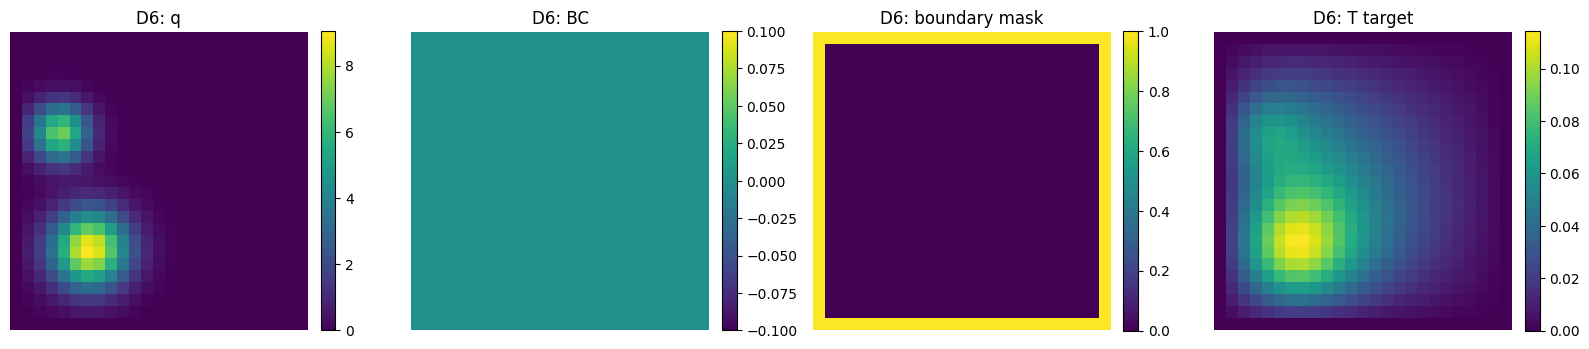

Saved: /kaggle/working/figures/dataset_sample_D6.png


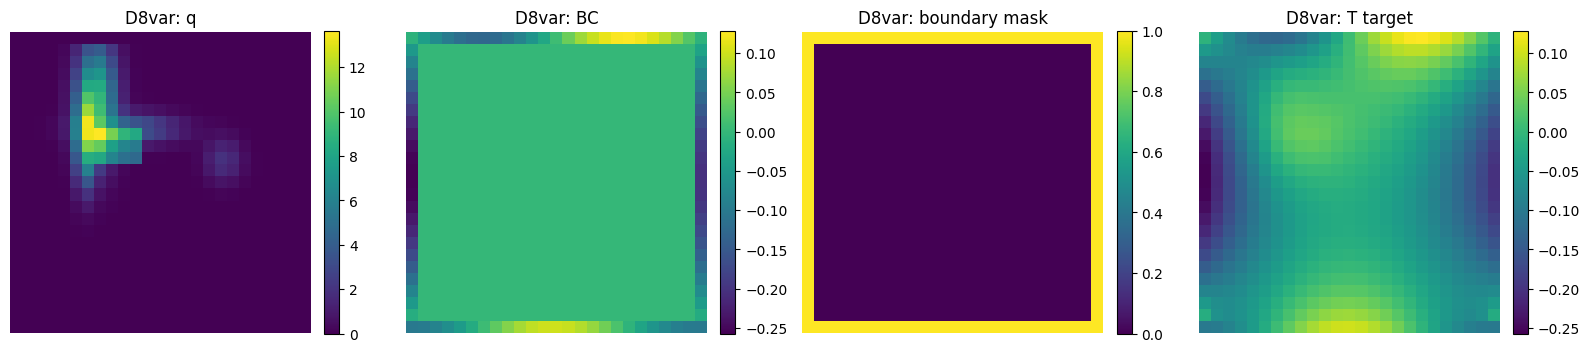

Saved: /kaggle/working/figures/dataset_sample_D8var.png


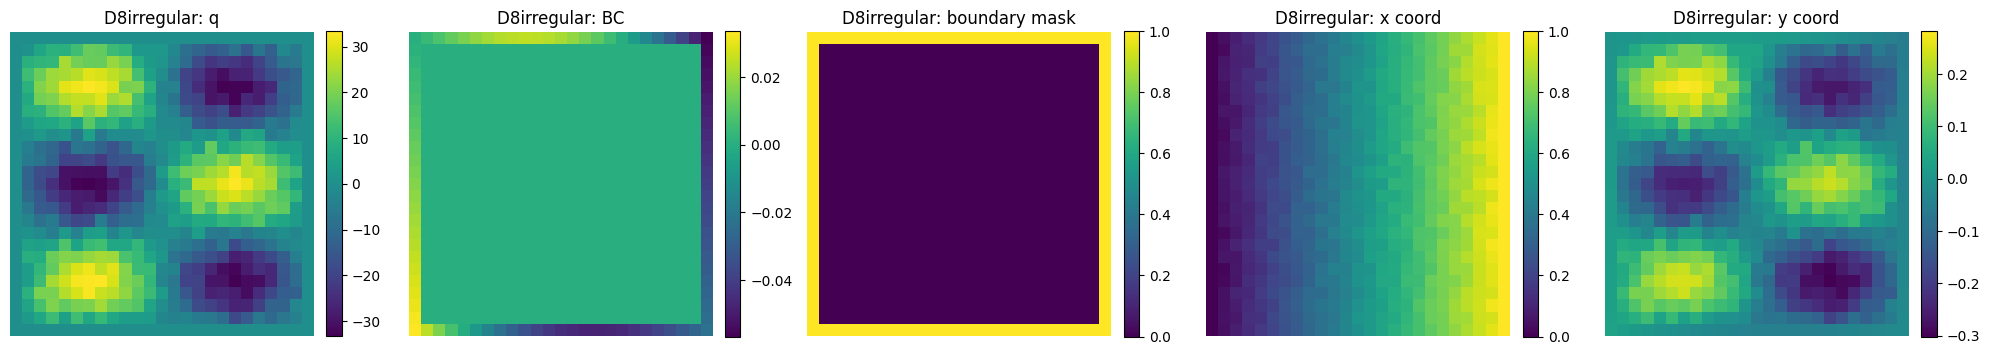

Saved: /kaggle/working/figures/dataset_sample_D8irregular.png


In [10]:
import matplotlib.pyplot as plt
for name, sample_npz in dataset_paths.items():
    z = np.load(sample_npz, allow_pickle=True)
    x_raw = z["X_train_raw"][0]
    y_raw = z["y_train_raw"][0, 0]
    n_cols = min(5, x_raw.shape[0] + 1)
    fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 4))
    if n_cols == 1:
        axes = [axes]
    titles = ["q", "BC", "boundary mask", "x coord", "y coord"][:x_raw.shape[0]] + ["T target"]
    imgs = list(x_raw[:n_cols-1]) + [y_raw]
    for ax, img, title in zip(axes, imgs, titles):
        im = ax.imshow(img)
        ax.set_title(f"{name}: {title}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    out = FIGURES_DIR / f"dataset_sample_{name}.png"
    plt.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)

## 7. Main training run

The main table uses the regular-grid reference dataset and the boundary-condition-variant dataset. The irregular stress test is handled separately unless explicitly included in the main table.


In [11]:
assert callable(append_result), "append_result helper is not defined. Run the setup cells again."

results_df = run_main_experiments(
    dataset_paths=dataset_paths,
    dataset_names=DATASETS_MAIN,
    models=MODELS,
    seeds=SEEDS_MAIN,
    lambda_physics=LAMBDA_PHYSICS_MAIN,
    epochs=EPOCHS_MAIN,
    batch_size=BATCH_SIZE,
    work_dir=str(WORK_DIR),
    force=FORCE_RETRAIN,
)
display(results_df.tail())

[D6_cnn_seed0_lambda0.01] epoch=001 train=0.08566 val_rmse=0.00575 phys=0.34594
[D6_cnn_seed0_lambda0.01] epoch=005 train=0.01130 val_rmse=0.00407 phys=0.17719
[D6_cnn_seed0_lambda0.01] epoch=010 train=0.00997 val_rmse=0.00182 phys=0.13132
[D6_cnn_seed0_lambda0.01] epoch=015 train=0.01253 val_rmse=0.00155 phys=0.10381
[D6_cnn_seed0_lambda0.01] epoch=020 train=0.00991 val_rmse=0.00101 phys=0.09387
[D6_cnn_seed0_lambda0.01] epoch=025 train=0.01039 val_rmse=0.00228 phys=0.10362
Early stopping at epoch 28, best epoch 13
TEST: {'dataset': 'D6', 'model': 'cnn', 'seed': 0, 'lambda_physics': 0.01, 'epochs_requested': 110, 'best_epoch': 13, 'training_time_sec': 62.52791380882263, 'params': 730041, 'model_size_mb': 2.7848854064941406, 'rmse': 0.001059443321763086, 'mae': 0.0006195631591796875, 'r2': 0.9994640520717204, 'physics_error': 0.09083510003983974, 'boundary_flux_error': 0.0004094260633185816, 'fft_error': 0.008102565382917723, 'mae_center': 0.0009443818707950413, 'mae_boundary': 0.00033

,dataset,model,seed,lambda_physics,epochs_requested,best_epoch,training_time_sec,params,model_size_mb,rmse,...,fft_error,mae_center,mae_boundary,latency_ms,flops,energy_per_inference_mj_proxy,normalization_protocol,strict_reproducibility,eqelm_hidden,eqelm_ridge
55,D8var,eQELM,5,0.0,0,0,0.061327,2400768,NaN,0.004721,...,0.032364,0.003199,0.003794,0.012039,3840000,NaN,train_only_channelwise_standardization,True,768.0,0.001
56,D8var,eQELM,6,0.0,0,0,0.061732,2400768,NaN,0.004630,...,0.031710,0.003320,0.003687,0.012543,3840000,NaN,train_only_channelwise_standardization,True,768.0,0.001
57,D8var,eQELM,7,0.0,0,0,0.061034,2400768,NaN,0.004673,...,0.031716,0.003171,0.003700,0.012466,3840000,NaN,train_only_channelwise_standardization,True,768.0,0.001
58,D8var,eQELM,8,0.0,0,0,0.060814,2400768,NaN,0.004629,...,0.032115,0.003180,0.003783,0.012096,3840000,NaN,train_only_channelwise_standardization,True,768.0,0.001
59,D8var,eQELM,9,0.0,0,0,0.060849,2400768,NaN,0.004620,...,0.031929,0.003321,0.003686,0.012596,3840000,NaN,train_only_channelwise_standardization,True,768.0,0.001


## 8. Optional irregular-mesh stress test

This block evaluates the models on the coordinate-jittered irregular stress dataset. It is useful for assessing graph-aware and coordinate-aware behavior.


In [12]:
RUN_OPTIONAL_IRREGULAR_STRESS_TEST = INCLUDE_IRREGULAR and not RUN_IRREGULAR_IN_MAIN_TABLE and RUN_MODE != "smoke"
IRREGULAR_STRESS_SEEDS = SEEDS_MAIN[:5]

if RUN_OPTIONAL_IRREGULAR_STRESS_TEST and "D8irregular" in dataset_paths:
    irregular_df = run_main_experiments(
        dataset_paths=dataset_paths,
        dataset_names=["D8irregular"],
        models=MODELS,
        seeds=IRREGULAR_STRESS_SEEDS,
        lambda_physics=LAMBDA_PHYSICS_MAIN,
        epochs=max(50, EPOCHS_MAIN // 2),
        batch_size=BATCH_SIZE,
        work_dir=str(WORK_DIR),
        force=FORCE_RETRAIN,
    )
    display(irregular_df.tail())
else:
    print("Optional irregular stress test skipped.")

[D8irregular_cnn_seed0_lambda0.01] epoch=001 train=0.33343 val_rmse=0.17958 phys=9.82331
[D8irregular_cnn_seed0_lambda0.01] epoch=005 train=0.04970 val_rmse=0.04005 phys=1.68754
[D8irregular_cnn_seed0_lambda0.01] epoch=010 train=0.04182 val_rmse=0.03145 phys=1.18049
[D8irregular_cnn_seed0_lambda0.01] epoch=015 train=0.03824 val_rmse=0.03304 phys=0.95385
[D8irregular_cnn_seed0_lambda0.01] epoch=020 train=0.03837 val_rmse=0.04340 phys=1.06809
[D8irregular_cnn_seed0_lambda0.01] epoch=025 train=0.03435 val_rmse=0.02786 phys=0.88856
[D8irregular_cnn_seed0_lambda0.01] epoch=030 train=0.03489 val_rmse=0.02962 phys=0.78269
[D8irregular_cnn_seed0_lambda0.01] epoch=035 train=0.03228 val_rmse=0.03171 phys=0.83896
[D8irregular_cnn_seed0_lambda0.01] epoch=040 train=0.03096 val_rmse=0.02673 phys=0.53777
[D8irregular_cnn_seed0_lambda0.01] epoch=045 train=0.03058 val_rmse=0.02594 phys=0.54382
[D8irregular_cnn_seed0_lambda0.01] epoch=050 train=0.02950 val_rmse=0.02582 phys=0.45612
[D8irregular_cnn_seed

,dataset,model,seed,lambda_physics,epochs_requested,best_epoch,training_time_sec,params,model_size_mb,rmse,...,fft_error,mae_center,mae_boundary,latency_ms,flops,energy_per_inference_mj_proxy,normalization_protocol,strict_reproducibility,eqelm_hidden,eqelm_ridge
70,D8irregular,eQELM,0,0.0,0,0,0.037255,3360768,NaN,0.028045,...,0.484963,0.023864,0.001289,0.014937,5760000,NaN,train_only_channelwise_standardization,True,768.0,0.001
71,D8irregular,eQELM,1,0.0,0,0,0.059389,3360768,NaN,0.028297,...,0.485700,0.023936,0.001368,0.017324,5760000,NaN,train_only_channelwise_standardization,True,768.0,0.001
72,D8irregular,eQELM,2,0.0,0,0,0.059247,3360768,NaN,0.028712,...,0.491252,0.024669,0.001315,0.017036,5760000,NaN,train_only_channelwise_standardization,True,768.0,0.001
73,D8irregular,eQELM,3,0.0,0,0,0.059687,3360768,NaN,0.028138,...,0.487483,0.024293,0.001328,0.017215,5760000,NaN,train_only_channelwise_standardization,True,768.0,0.001
74,D8irregular,eQELM,4,0.0,0,0,0.059554,3360768,NaN,0.028137,...,0.481845,0.023961,0.001278,0.016958,5760000,NaN,train_only_channelwise_standardization,True,768.0,0.001


## 9. Physics-regularization ablation

This block studies the trade-off between predictive accuracy and physics consistency over a fine grid of `lambda_physics` values.


In [13]:
if RUN_LAMBDA_ABLATION:
    ablation_df = run_lambda_ablation(
        dataset_paths=dataset_paths,
        dataset_name=ABLATION_DATASET,
        model_name=ABLATION_MODEL,
        seeds=SEEDS_ABLATION,
        lambdas=LAMBDA_GRID,
        epochs=EPOCHS_ABLATION,
        batch_size=BATCH_SIZE,
        work_dir=str(WORK_DIR),
        force=True,
    )
    display(ablation_df.tail())
else:
    print("Ablation disabled.")

[D6_cnn_seed0_lambda0] epoch=001 train=0.07013 val_rmse=0.00491 phys=0.85899
[D6_cnn_seed0_lambda0] epoch=005 train=0.00951 val_rmse=0.00161 phys=0.42042
[D6_cnn_seed0_lambda0] epoch=010 train=0.00859 val_rmse=0.00130 phys=0.29003
[D6_cnn_seed0_lambda0] epoch=015 train=0.01097 val_rmse=0.00133 phys=0.25157
[D6_cnn_seed0_lambda0] epoch=020 train=0.00834 val_rmse=0.00264 phys=0.26900
[D6_cnn_seed0_lambda0] epoch=025 train=0.00891 val_rmse=0.00167 phys=0.22980
Early stopping at epoch 29, best epoch 14
TEST: {'dataset': 'D6', 'model': 'cnn', 'seed': 0, 'lambda_physics': 0.0, 'epochs_requested': 75, 'best_epoch': 14, 'training_time_sec': 66.24857521057129, 'params': 730041, 'model_size_mb': 2.7848854064941406, 'rmse': 0.0008871026775018258, 'mae': 0.0006045548929850261, 'r2': 0.9996242362155313, 'physics_error': 0.2744634946187337, 'boundary_flux_error': 0.0003953616542275995, 'fft_error': 0.008752989039445916, 'mae_center': 0.0008752792491577566, 'mae_boundary': 0.0002696368343701276, 'lat

,dataset,model,seed,lambda_physics,epochs_requested,best_epoch,training_time_sec,params,model_size_mb,rmse,...,physics_error,boundary_flux_error,fft_error,mae_center,mae_boundary,latency_ms,flops,energy_per_inference_mj_proxy,normalization_protocol,strict_reproducibility
70,D6,CNN,0,100.0,75,14,66.672515,730041,2.784885,0.004455,...,0.106100,0.000912,0.035245,0.003357,0.003947,0.083377,202424000,NaN,train_only_channelwise_standardization,True
71,D6,CNN,1,100.0,75,35,115.252054,730041,2.784885,0.004880,...,0.061874,0.000976,0.042483,0.003303,0.004881,0.082967,202424000,NaN,train_only_channelwise_standardization,True
72,D6,CNN,2,100.0,75,9,55.691842,730041,2.784885,0.005618,...,0.061441,0.000847,0.043823,0.003276,0.005134,0.082827,202424000,NaN,train_only_channelwise_standardization,True
73,D6,CNN,3,100.0,75,2,39.542054,730041,2.784885,0.005808,...,0.193588,0.001330,0.047538,0.003637,0.005124,0.082930,202424000,NaN,train_only_channelwise_standardization,True
74,D6,CNN,4,100.0,75,4,44.154614,730041,2.784885,0.003751,...,0.135932,0.000794,0.025695,0.003663,0.002560,0.083304,202424000,NaN,train_only_channelwise_standardization,True


## 10. Summary tables and statistical tests

This block aggregates seed-level results, computes uncertainty statistics and exports paired statistical comparisons.


In [14]:
main_csv = RESULTS_DIR / "results_ieee_access.csv"
summary = summarize_mean_std(main_csv)
summary_path = RESULTS_DIR / "summary_mean_std.csv"
summary.to_csv(summary_path, index=False)

cols = ["dataset", "model", "n_runs", "rmse_fmt", "rmse_fmt_ci95", "mae_fmt", "r2_fmt", "physics_error_fmt", "boundary_flux_error_fmt", "fft_error_fmt", "latency_ms_fmt", "flops_fmt", "energy_per_inference_mj_proxy_fmt"]
display(summary[[c for c in cols if c in summary.columns]])
print("Saved:", summary_path)

for metric in ["rmse", "mae", "physics_error", "latency_ms"]:
    tests = paired_effect_size_and_tests(main_csv, metric=metric, baseline_model="cnn")
    out = RESULTS_DIR / f"paired_tests_{metric}.csv"
    tests.to_csv(out, index=False)
    print("Saved:", out)
    display(tests)

,dataset,model,n_runs,rmse_fmt,rmse_fmt_ci95,mae_fmt,r2_fmt,physics_error_fmt,boundary_flux_error_fmt,fft_error_fmt,latency_ms_fmt,flops_fmt
0,D6,CNN,10,0.0009432 ± 0.00017,0.0009432 ± 0.00011,0.0006448 ± 9.8e-05,0.9996 ± 0.00015,0.09053 ± 0.017,0.0004262 ± 9.2e-05,0.00789 ± 0.0014,0.08392 ± 0.00052,2.024e+08 ± 0
1,D6,GNN,10,0.009036 ± 5.2e-05,0.009036 ± 3.2e-05,0.006076 ± 2.7e-05,0.961 ± 0.00045,1.3 ± 0.011,0.002072 ± 8.8e-06,0.06737 ± 0.00046,0.3069 ± 0.002,2.27e+08 ± 0
2,D6,eQELM,10,0.001666 ± 6.6e-05,0.001666 ± 4.1e-05,0.0008043 ± 1.8e-05,0.9987 ± 0.0001,0.07957 ± 0.00064,0.0002082 ± 4.5e-06,0.006528 ± 0.0001,0.0127 ± 0.00064,3.84e+06 ± 0
3,D8irregular,CNN,5,0.02699 ± 0.00033,0.02699 ± 0.00029,0.01821 ± 0.00025,0.9858 ± 0.00035,0.534 ± 0.081,0.01881 ± 0.00011,0.5307 ± 0.0031,0.0851 ± 0.00047,2.033e+08 ± 0
4,D8irregular,GNN,5,0.07245 ± 0.00013,0.07245 ± 0.00011,0.04784 ± 8.5e-05,0.898 ± 0.00036,4.931 ± 0.068,0.02313 ± 6.6e-05,0.7946 ± 0.0024,0.3076 ± 0.0019,2.277e+08 ± 0
5,D8irregular,eQELM,5,0.02827 ± 0.00027,0.02827 ± 0.00023,0.0183 ± 0.00013,0.9845 ± 0.00029,42.73 ± 0.093,0.01594 ± 0.00012,0.4862 ± 0.0035,0.01669 ± 0.00099,5.76e+06 ± 0
6,D8var,CNN,10,0.001893 ± 0.00042,0.001893 ± 0.00026,0.00139 ± 0.00031,0.9996 ± 0.00019,0.178 ± 0.053,0.001448 ± 0.00048,0.02576 ± 0.0061,0.08371 ± 0.00057,2.024e+08 ± 0
7,D8var,GNN,10,0.025 ± 0.00021,0.025 ± 0.00013,0.01568 ± 0.00021,0.9265 ± 0.0012,2.663 ± 0.085,0.004354 ± 0.00013,0.1746 ± 0.0027,0.3075 ± 0.0014,2.27e+08 ± 0
8,D8var,eQELM,10,0.004724 ± 0.0001,0.004724 ± 6.4e-05,0.003043 ± 4e-05,0.9974 ± 0.00012,0.1655 ± 0.0011,0.001219 ± 2.1e-05,0.03218 ± 0.00046,0.01209 ± 0.00043,3.84e+06 ± 0


Saved: /kaggle/working/results/summary_mean_std.csv
Saved: /kaggle/working/results/paired_tests_rmse.csv


,dataset,baseline,model,metric,n_pairs,mean_difference_comparison_minus_baseline,cohen_dz,wilcoxon_statistic,p_value
0,D6,cnn,GNN,rmse,10,0.008093,48.935292,0.0,0.001953
1,D6,cnn,eQELM,rmse,10,0.000723,3.239886,0.0,0.001953
2,D8irregular,cnn,GNN,rmse,5,0.045458,116.756482,0.0,0.062500
3,D8irregular,cnn,eQELM,rmse,5,0.001277,2.923667,0.0,0.062500
4,D8var,cnn,GNN,rmse,10,0.023104,50.884810,0.0,0.001953
5,D8var,cnn,eQELM,rmse,10,0.002831,7.169518,0.0,0.001953


Saved: /kaggle/working/results/paired_tests_mae.csv


,dataset,baseline,model,metric,n_pairs,mean_difference_comparison_minus_baseline,cohen_dz,wilcoxon_statistic,p_value
0,D6,cnn,GNN,mae,10,0.005431,59.010497,0.0,0.001953
1,D6,cnn,eQELM,mae,10,0.000160,1.471247,0.0,0.001953
2,D8irregular,cnn,GNN,mae,5,0.029634,96.986608,0.0,0.062500
3,D8irregular,cnn,eQELM,mae,5,0.000093,0.313471,4.0,0.437500
4,D8var,cnn,GNN,mae,10,0.014292,43.207789,0.0,0.001953
5,D8var,cnn,eQELM,mae,10,0.001653,5.708987,0.0,0.001953


Saved: /kaggle/working/results/paired_tests_physics_error.csv


,dataset,baseline,model,metric,n_pairs,mean_difference_comparison_minus_baseline,cohen_dz,wilcoxon_statistic,p_value
0,D6,cnn,GNN,physics_error,10,1.209002,56.138417,0.0,0.001953
1,D6,cnn,eQELM,physics_error,10,-0.010961,-0.645272,10.0,0.083984
2,D8irregular,cnn,GNN,physics_error,5,4.396557,39.065835,0.0,0.062500
3,D8irregular,cnn,eQELM,physics_error,5,42.195716,252.136955,0.0,0.062500
4,D8var,cnn,GNN,physics_error,10,2.485160,35.775041,0.0,0.001953
5,D8var,cnn,eQELM,physics_error,10,-0.012526,-0.239533,21.0,0.556641


Saved: /kaggle/working/results/paired_tests_latency_ms.csv


,dataset,baseline,model,metric,n_pairs,mean_difference_comparison_minus_baseline,cohen_dz,wilcoxon_statistic,p_value
0,D6,cnn,GNN,latency_ms,10,0.222993,103.363845,0.0,0.001953
1,D6,cnn,eQELM,latency_ms,10,-0.071221,-68.329538,0.0,0.001953
2,D8irregular,cnn,GNN,latency_ms,5,0.222463,98.239600,0.0,0.062500
3,D8irregular,cnn,eQELM,latency_ms,5,-0.068406,-85.466399,0.0,0.062500
4,D8var,cnn,GNN,latency_ms,10,0.223824,182.545063,0.0,0.001953
5,D8var,cnn,eQELM,latency_ms,10,-0.071621,-145.183716,0.0,0.001953


## 11. Figures

This block generates publication-support figures from the benchmark outputs.


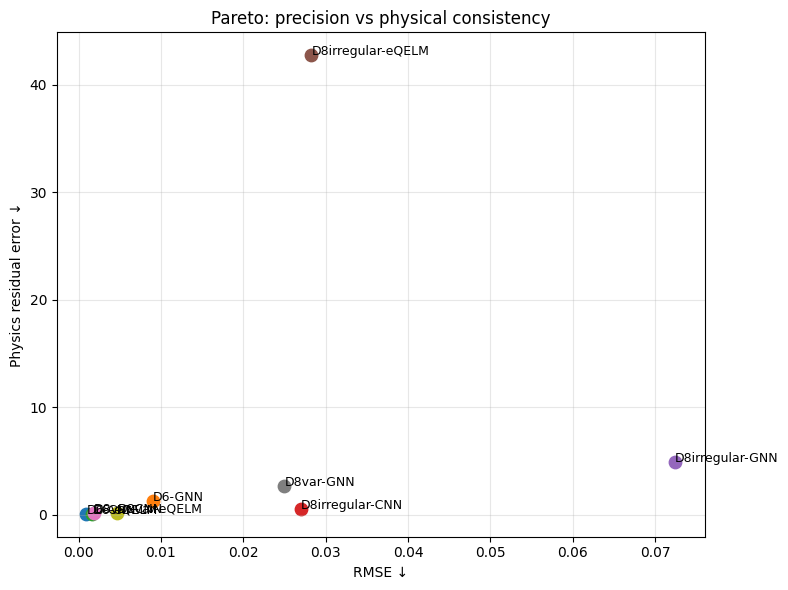

Saved: /kaggle/working/figures/pareto_precision_physics.png


,dataset,model,rmse,physics_error,is_pareto_efficient
0,D6,CNN,0.000943,0.090529,True
1,D6,eQELM,0.001666,0.079568,True
2,D8irregular,CNN,0.026988,0.534010,True
3,D8var,CNN,0.001893,0.177993,True
4,D8var,eQELM,0.004724,0.165467,True


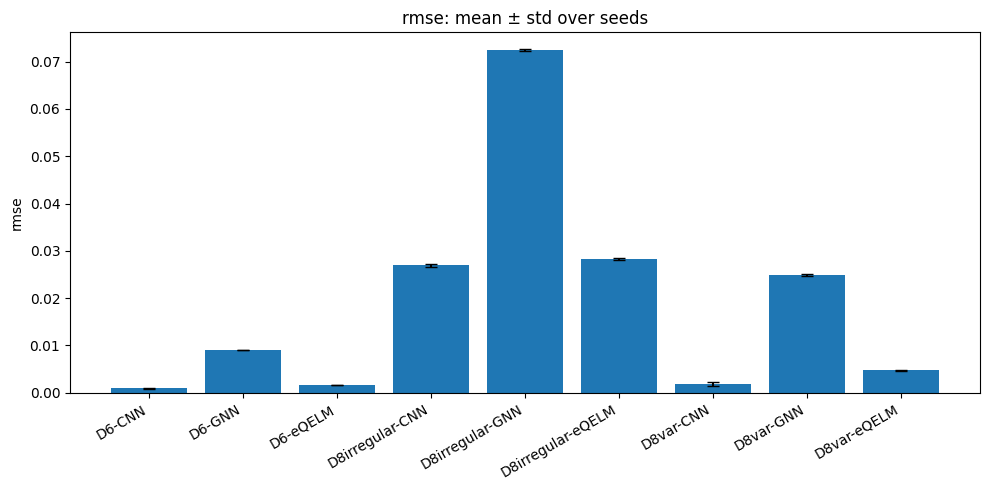

Saved: /kaggle/working/figures/rmse_mean_std.png


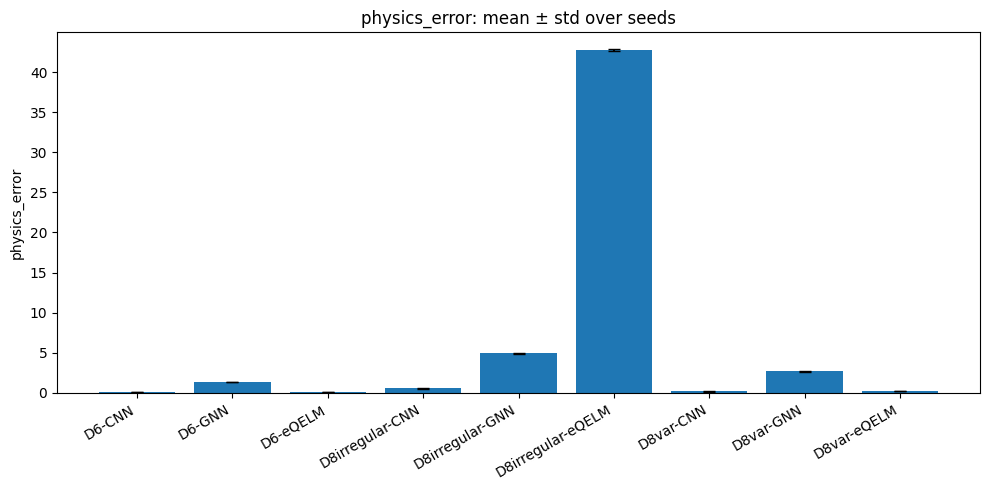

Saved: /kaggle/working/figures/physics_error_mean_std.png


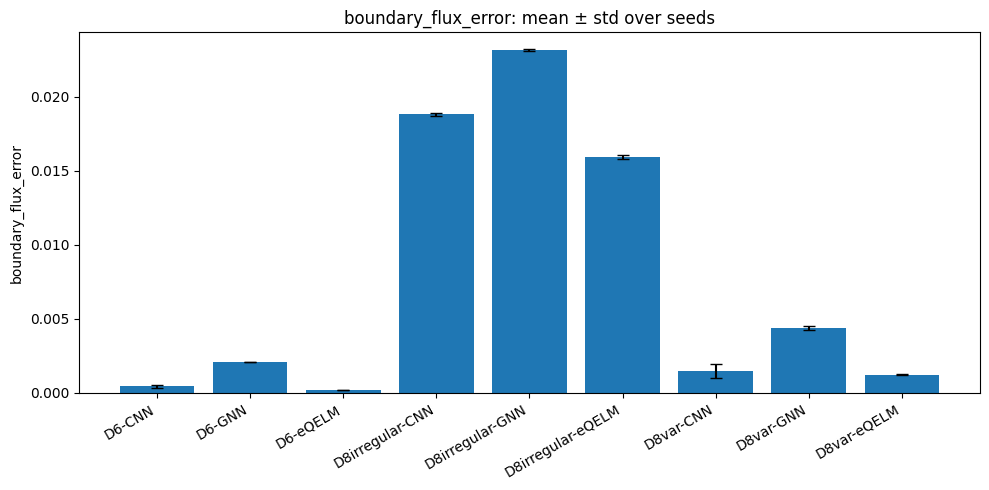

Saved: /kaggle/working/figures/boundary_flux_error_mean_std.png


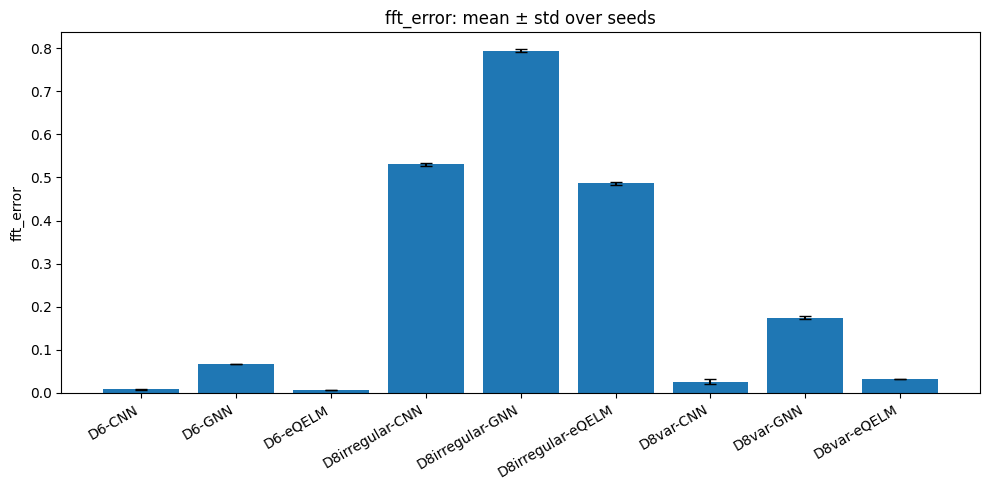

Saved: /kaggle/working/figures/fft_error_mean_std.png


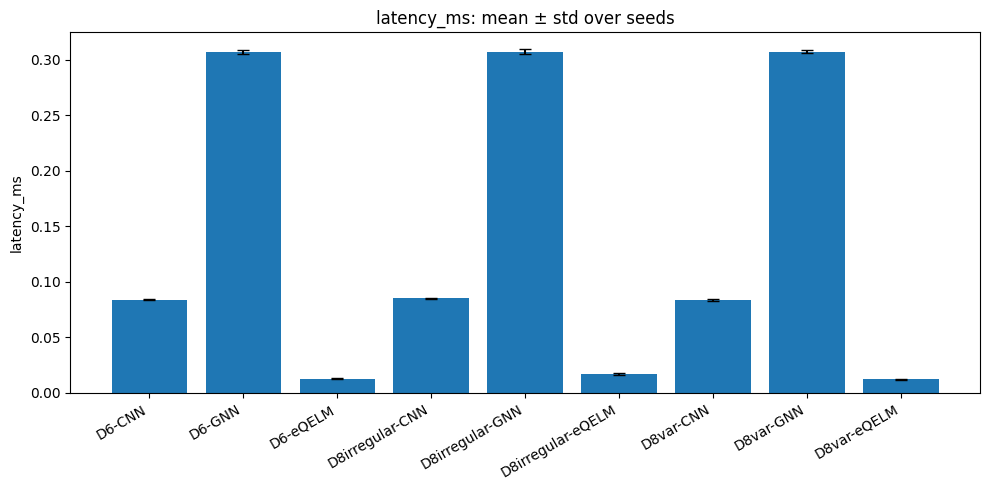

Saved: /kaggle/working/figures/latency_ms_mean_std.png


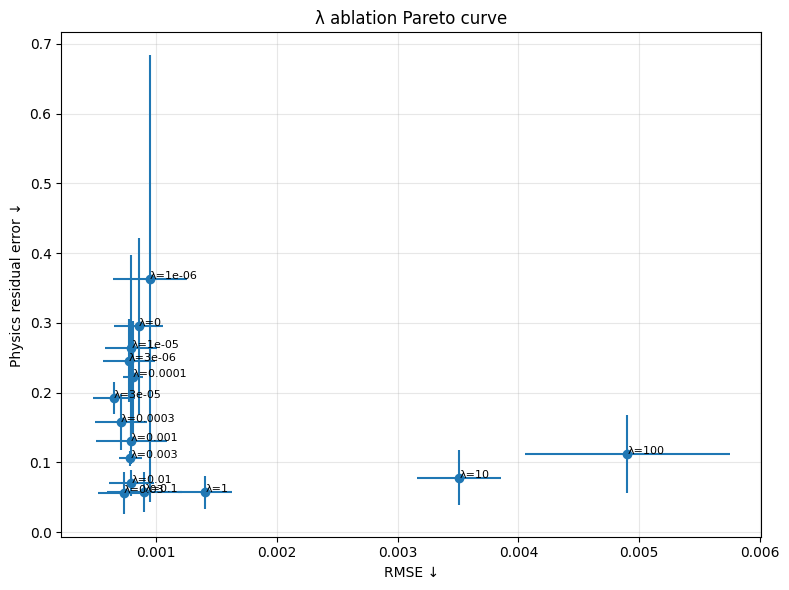

Saved: /kaggle/working/figures/lambda_ablation_pareto.png


In [15]:
plot_pareto(str(main_csv), out_path=str(FIGURES_DIR / "pareto_precision_physics.png"))
pareto_table = export_pareto_table(str(main_csv), out_path=RESULTS_DIR / "pareto_frontier_table.csv")
display(pareto_table)
for metric in ["rmse", "physics_error", "boundary_flux_error", "fft_error", "latency_ms"]:
    try:
        plot_metric_bars(str(main_csv), metric=metric, out_path=str(FIGURES_DIR / f"{metric}_mean_std.png"))
    except Exception as e:
        print("Could not plot", metric, e)

ablation_csv = RESULTS_DIR / "results_lambda_ablation.csv"
if not ablation_csv.exists():
    ablation_csv = RESULTS_DIR / "ablation_lambda.csv"
if ablation_csv.exists():
    abd = pd.read_csv(ablation_csv)
    abd_summary = abd.groupby("lambda_physics", as_index=False).agg(
        rmse=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        physics_error=("physics_error", "mean"),
        physics_std=("physics_error", "std"),
    )
    abd_summary.to_csv(RESULTS_DIR / "ablation_lambda_summary.csv", index=False)
    plt.figure(figsize=(8,6))
    plt.errorbar(abd_summary["rmse"], abd_summary["physics_error"], xerr=abd_summary["rmse_std"], yerr=abd_summary["physics_std"], fmt="o")
    for _, r in abd_summary.iterrows():
        plt.text(r["rmse"], r["physics_error"], f"λ={r['lambda_physics']:g}", fontsize=8)
    plt.xlabel("RMSE ↓")
    plt.ylabel("Physics residual error ↓")
    plt.title("λ ablation Pareto curve")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = FIGURES_DIR / "lambda_ablation_pareto.png"
    plt.savefig(out, dpi=220)
    plt.show()
    print("Saved:", out)

## 12. Additional physical diagnostics

This block exports representative prediction maps and frequency-domain error diagnostics.


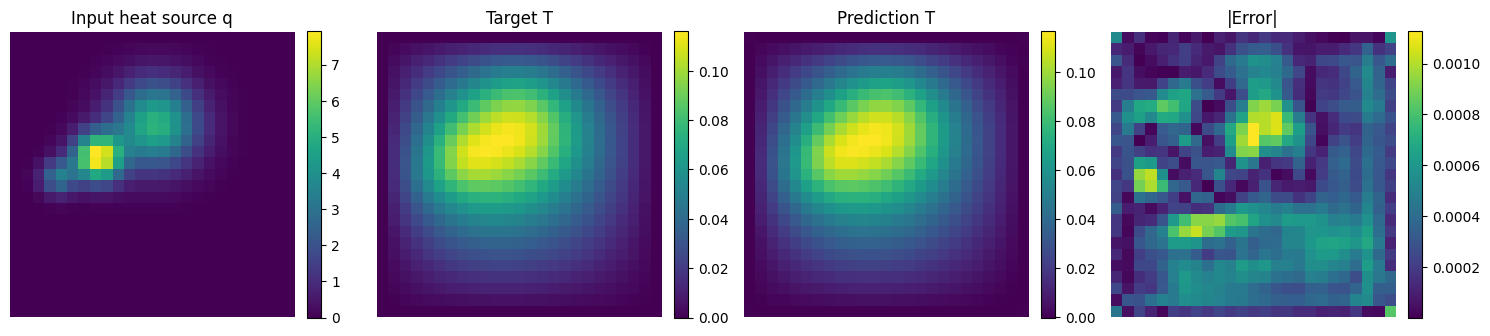

Saved: /kaggle/working/figures/sample_prediction_D6_CNN.png


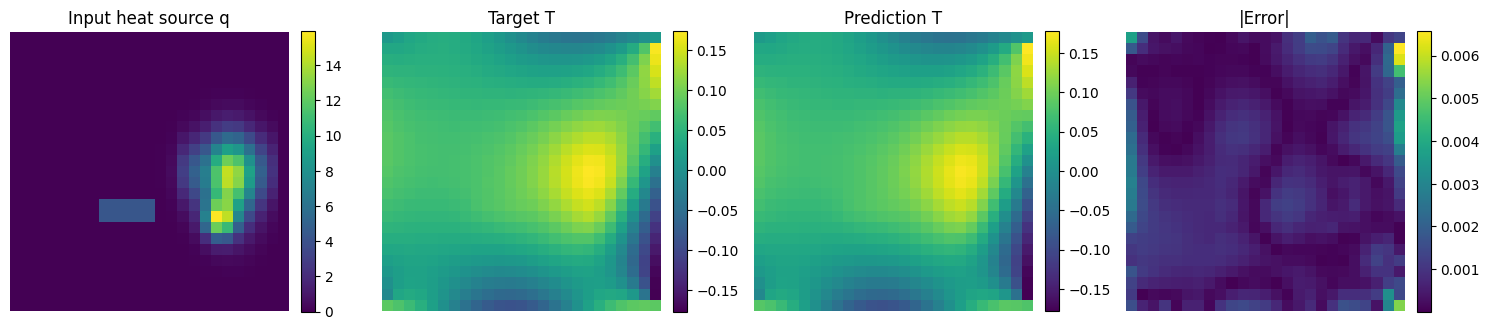

Saved: /kaggle/working/figures/sample_prediction_D8var_CNN.png


In [16]:
for ds_name in DATASETS_MAIN:
    ckpts = sorted((WORK_DIR / "checkpoints").glob(f"{ds_name}_cnn_seed0_lambda*.pt"))
    if ckpts:
        plot_sample_predictions(
            npz_path=dataset_paths[ds_name],
            ckpt_path=str(ckpts[0]),
            model_name="cnn",
            out_path=str(FIGURES_DIR / f"sample_prediction_{ds_name}_CNN.png")
        )
    else:
        print("No checkpoint found for", ds_name)

## 13. Reviewer package

This block packages the notebook outputs, configuration, manifests, raw results, figures and environment records.


In [17]:
try:
    latex_cols = ["dataset", "model", "n_runs", "rmse_fmt", "mae_fmt", "r2_fmt", "physics_error_fmt", "latency_ms_fmt"]
    latex_df = summary[[c for c in latex_cols if c in summary.columns]].copy()
    latex_path = RESULTS_DIR / "table_main_results.tex"
    latex_path.write_text(latex_df.to_latex(index=False, escape=False), encoding="utf-8")
    print("Saved:", latex_path)
except Exception as e:
    print("LaTeX export failed:", e)

Saved: /kaggle/working/results/table_main_results.tex


## 14. Final checklist

Use this checklist before transferring the final results into the manuscript.


In [18]:
archive_path = create_reviewer_package(work_dir=str(WORK_DIR), notebook_name="IEEE_Access_Heat_Benchmark_REVIEWER_READY_Kaggle_T4_CLEAN_EN_SCALED_IMPROVED.ipynb")
print("Final reviewer archive:", archive_path)

print("\nGenerated files:")
for p in sorted(WORK_DIR.rglob("*")):
    if p.is_file() and any(part in ["results", "figures", "reviewer_artifacts"] for part in p.parts):
        print(" -", p.relative_to(WORK_DIR))

Final reviewer archive: /kaggle/working/ieee_access_reviewer_package.zip

Generated files:
 - figures/boundary_flux_error_mean_std.png
 - figures/dataset_sample_D6.png
 - figures/dataset_sample_D8irregular.png
 - figures/dataset_sample_D8var.png
 - figures/fft_error_mean_std.png
 - figures/lambda_ablation_pareto.png
 - figures/latency_ms_mean_std.png
 - figures/pareto_precision_physics.png
 - figures/physics_error_mean_std.png
 - figures/rmse_mean_std.png
 - figures/sample_prediction_D6_CNN.png
 - figures/sample_prediction_D8var_CNN.png
 - results/ablation_lambda.csv
 - results/ablation_lambda_summary.csv
 - results/dataset_manifest.csv
 - results/dataset_validation_audit.csv
 - results/history_D6_cnn_seed0_lambda0.0001.csv
 - results/history_D6_cnn_seed0_lambda0.0003.csv
 - results/history_D6_cnn_seed0_lambda0.001.csv
 - results/history_D6_cnn_seed0_lambda0.003.csv
 - results/history_D6_cnn_seed0_lambda0.01.csv
 - results/history_D6_cnn_seed0_lambda0.03.csv
 - results/history_D6_cnn_s